# **Who Turns to AI for Schoolwork?: Socioeconomic and Educational Predictors of Student Interest in the ChatGPT Era**

This notebook documents the end-to-end data acquisition and analysis pipeline for the paper. See `paper/main.tex` for the abstract, introduction, related work, and full discussion.

## Research question

What preexisting socioeconomic and educational achievement conditions from a pre-ChatGPT era (2019) predict a US region's later interest in GenAI for schoolwork after ChatGPT's release (2023-2025)?

## Approach

1. Pull Google search data from 2023-2025 on AI use by students for schoolwork.
2. Take a 2019 "snapshot" of America, documenting regional socioeconomic and educational conditions.
3. Run feature-selection and modelling to identify the most important socioeconomic and educational predictors of the search data.
4. Cluster regions and examine how search data relates to those clusters.
5. Build a predictive model from the selected 2019 variables.

## Data

Student interest in using AI for schoolwork is measured via Google Trends, which scores search interest per region. The query window is 2023-2025, covering ChatGPT's release through the most recent full period available at pull time. Google Trends reports values at Nielsen Designated Market Area (DMA) resolution, a proprietary geographic system covering the continental U.S., Hawaii, and parts of Alaska (Nielsen, 2025). DMA is the smallest available geographic unit from Google Trends, which does not consistently provide city- or county-level data.

To represent student search interest in AI for schoolwork, 70+ search terms were selected after exploratory Google Trends queries that assessed volume and reviewed related queries. The terms span AI schoolwork tools, AI techniques for homework, school rules regarding AI, and similar areas, and deliberately exclude broad terms like "AI" or "ChatGPT" on their own, since these are used by many non-student populations and would add noise.

The 2019 socioeconomic and educational snapshot uses American Community Survey (ACS) data from the U.S. Census Bureau for income, poverty, population, race, and educational attainment per county (U.S. Census Bureau, 2020), and Stanford Education Data Archive (SEDA) data for county-level student achievement up to 2019 (Reardon et al., 2025; Stanford Educational Opportunity Project, n.d.). 2019 is the most recent year in SEDA and is also pre-COVID, avoiding the regionally uneven lockdown effects that would complicate a 2021 or 2022 snapshot.

The county-level ACS and SEDA data are mapped to DMA geography using a public county-to-DMA crosswalk on Kaggle (Kapastor, 2021).

# Code and Results

The cells below run the full data acquisition and analysis pipeline, with explanatory prose between each step.

### Install packages

The cell below installs all packages required by this notebook from `requirements.txt`.

In [ ]:
!pip install -r requirements.txt

### Query Google Trends

The Pytrends library, an unofficial API for Google Trends (Hogue & DeWilde, 2023), is used to acquire the search data. Pytrends is open source, so others can reproduce the methods and results without paid credentials. The region is set to US, the timeframe to January 1st, 2023 through July 31st, 2025, and the regional resolution to DMA (Designated Market Area). DMA is the smallest geographic unit consistently available from Google Trends, which does not provide reliable city- or county-level data.

Keywords are queried in batches of 5, the maximum allowed per query by Google Trends (Funnel, n.d.). Google Trends does not provide raw search volume but rather relative search interest between keywords in a query along a 0-100 scale, with each keyword's interest scaled relative to the keyword in the batch with the highest volume (Google News Initiative, n.d.). Querying each keyword individually, or batching them arbitrarily in groups of 5, would make the resulting scores non-comparable across the 70+ keywords. To produce a single comparable scale, we use an anchoring strategy: each batch of 4 target keywords also includes a single anchor keyword ("homework") with consistently high search volume, allowing the per-batch scales to be stitched together by normalizing on the anchor.

The 19 randomly-combined batches used in this study are hardcoded below for reproducibility.

#### Keyword selection strategy

Preliminary exploratory queries through the Google Trends interface — testing volume across keywords and regions, and following "related queries" — yielded a final list of 72 keywords (Google Trends, n.d.), grouped as:

- Practical homework help using AI
- Specific AI tools for schoolwork
- AI techniques for schoolwork (e.g. prompt engineering)
- AI support for writing and essays
- Subject-specific AI help (other than writing)
- Studying and exam prep support using AI
- Accuracy and limitations of AI for schoolwork
- AI plagiarism, AI usage policy, and AI detection avoidance

These groupings are intended to capture the range of angles from which students might search for AI schoolwork topics on Google.

To restrict the data to student queries, only terms exclusive to a student context were retained. Generic AI-related keywords like "AI writing help" or "ChatGPT for efficiency" were excluded, as were broad terms like "AI" and "Gemini" on their own, since both classes of term would introduce substantial non-student noise.

In [ ]:
# Randomly batched keywords,
# each with the same anchor ("homework"), 
# hard-coded for better documentation
batches = [
    ['homework', 'AI biology homework', 'PhotoMath alternatives', 'AI foreign language homework', 'homework prompts for AI'],
    ['homework', 'AI for writing essays', 'how to prompt AI for homework', 'Socratic app homework', 'AI flashcards'],
    ['homework', 'AI for literature review', 'Best AI prompts for homework', 'AI homework helper app', 'Academic integrity AI'],
    ['homework', 'AI plagiarism risk', 'AI practice problems', 'AI homework answers wrong', 'how accurate are AI detectors'],
    ['homework', 'AI for group projects', 'AI for high school', 'Is Claude allowed for school?', 'AI to generate discussion questions'],
    ['homework', 'AI for language learning homework', 'Gemini homework help', 'Is ChatGPT allowed for school?', 'AI study techniques'],
    ['homework', 'paraphrasing tool to avoid plagiarism', 'AI to summarize textbooks', 'is using AI cheating', 'AI homework Discord bot'],
    ['homework', 'how to avoid AI detection', 'AI for math problems', 'AI for studying', 'AI prompt engineering for school'],
    ['homework', 'can teachers detect AI', 'AI for book report', 'Turnitin AI detection', 'School policy on AI'],
    ['homework', 'AI essay writer', 'AI economics help', 'how to cite AI', 'AI calculus solver'],
    ['homework', 'AI English essay', 'Khanmigo', 'bypass AI checker', 'AI chemistry homework'],
    ['homework', 'ChatGPT for homework', 'AI citation generator', 'AI for lab report', 'AI hallucination homework'],
    ['homework', 'how to fact-check AI homework', 'make AI undetectable', 'AI for college students', 'AI for studying for tests'],
    ['homework', 'is using QuillBot plagiarism', 'AI for exam prep', 'AI history essay help', 'AI homework inaccuracies'],
    ['homework', 'University AI policy', 'AI for presentation outline', 'when AI gets homework wrong', 'AI learning assistant'],
    ['homework', 'Is Gemini allowed for school?', 'AI homework solver', 'Claude for homework', 'AI homework help'],
    ['homework', 'AI statistics solver', 'AI physics problems', 'homework AI app', 'PhotoMath'],
    ['homework', 'how to use AI for research', 'AI homework mistakes', 'QuillBot for school', 'Copilot for students'],
    ['homework', 'AI tutor app']
]

In [45]:
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import time, random

# Variables to configure the querying
HL, TZ, GEO = 'en-US', 360, 'US' # Basic google trends config
TIMEFRAME = '2023-01-01 2025-07-31'
SLEEP_RANGE = (15, 25) # Out of respect to the API
MAX_RETRIES = 5 # lots of retries, to ensure no missing data
BACKOFF_BASE = 20
TERMS_PER_REQUEST = 5   # 5 is the maximum Google allows

# Define the process in a single function
def get_search_interest(pytrends, keyword_batches, timeframe, anchor='homework'):
    all_batches = []

    for batch_idx, batch in enumerate(keyword_batches, 1):
        print(f"Batch {batch_idx}: {batch}")

        # Try with up to the max retries,
        # in case some fail due to rate limiting or API errors
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                pytrends.build_payload(batch, geo=GEO, timeframe=timeframe)

                # Get regularly (weekly/daily) interest per keyword
                # returns each keyword on its own 0–100 scale (100 at that keyword’s peak in the time window)
                df_time = pytrends.interest_over_time()
                if df_time.empty:
                    continue
                df_time = df_time.drop('isPartial', axis=1, errors='ignore')

                # set regional level to DMA
                # Includes low-volume DMAs too, via second argument 
                # Returns per-keyword 0–100, 100 at that keyword’s top DMA
                df_region = pytrends.interest_by_region(resolution='DMA', inc_low_vol=True)
                if df_region.empty:
                    continue

                # Sum each keyword across the whole timeframe, to get total interest
                # Divide by 100 to get it on 0-100 scale
                # Multiply each DMA by its keyword's factor, to get per-DMA values proportional to total interest
                # This turns the per-DMA 0–100 ranks into pseudo-volume units proportional to how active keyword was over time
                keyword_totals = df_time.sum(numeric_only=True)
                df_region = df_region.reset_index().rename(columns={'geoName': 'dma_name'})
                cols = [c for c in df_region.columns if c != 'dma_name']

                factors = keyword_totals.reindex(cols).fillna(0) / 100
                df_region[cols] = df_region[cols].mul(factors, axis=1)

                # change wide format to long format
                df = df_region.melt(id_vars='dma_name', var_name='keyword', value_name='score')
                df['batch'] = batch_idx

                # sleep, for rate limiting
                all_batches.append(df)
                time.sleep(random.uniform(*SLEEP_RANGE))
                break

            except Exception as e:
                wait = BACKOFF_BASE * attempt + random.uniform(0, 10)
                print(f"Attempt {attempt} failed: {e}, it'll now sleep {wait:.1f} seconds")
                time.sleep(wait)
        else:
            print(f"Batch {batch_idx} exhausted all retries")

    # Concatenate all the batches
    df_all = pd.concat(all_batches, ignore_index=True)

    # Compute anchor scores per DMA and batch
    anchor_df = (
        df_all.loc[df_all['keyword'] == anchor, ['dma_name', 'batch', 'score']]
              .rename(columns={'score': 'anchor_score'})
    )
    # compute a global anchor baseline per Dma,
    # with the median for each becoming the DMA's target anchor level
    global_baseline = (
        anchor_df.groupby('dma_name', as_index=False)['anchor_score']
                 .median()
                 .rename(columns={'anchor_score': 'anchor_baseline'})
    )

    # Merge and compute a scale factor per row
    m = (df_all
         .merge(anchor_df, on=['dma_name', 'batch'], how='left')
         .merge(global_baseline, on='dma_name', how='left'))

    scale_factor = np.where(
        (m['anchor_score'] > 0) & m['anchor_baseline'].notna(),
        m['anchor_baseline'] / m['anchor_score'],
        np.nan
    )
    # Apply the scale factor to the keyword scores
    m['score_scaled'] = np.where(
        (pd.notna(scale_factor)) & (m['score'] > 0),
        m['score'] * scale_factor,
        np.where(m['score'] == 0, np.nan, m['score'])
    )

    # final aggregation (excluding the anchor)
    final_data = (
        m[m['keyword'] != anchor]
        .groupby(['dma_name', 'keyword'], as_index=False)['score_scaled']
        .mean()
        .rename(columns={'score_scaled': 'search_interest'})
        .sort_values(['dma_name', 'keyword'], kind='stable')
        .reset_index(drop=True)
    )

    return final_data

random.seed(5)
pytrends = TrendReq(hl=HL, tz=TZ)

search_interest_df = get_search_interest(pytrends, batches, TIMEFRAME, anchor='homework')

if search_interest_df.empty:
    raise SystemExit("Error -no data in the dataframe")

search_interest_df.to_csv("search_interest_data.csv", index=False, encoding='utf-8')
print("Completed gathering Google Trends data")

Batch 1: ['homework', 'AI biology homework', 'PhotoMath alternatives', 'AI foreign language homework', 'homework prompts for AI']
Batch 2: ['homework', 'AI for writing essays', 'how to prompt AI for homework', 'Socratic app homework', 'AI flashcards']
Batch 3: ['homework', 'AI for literature review', 'Best AI prompts for homework', 'AI homework helper app', 'Academic integrity AI']
Batch 4: ['homework', 'AI plagiarism risk', 'AI practice problems', 'AI homework answers wrong', 'how accurate are AI detectors']
Batch 5: ['homework', 'AI for group projects', 'AI for high school', 'Is Claude allowed for school?', 'AI to generate discussion questions']
Batch 6: ['homework', 'AI for language learning homework', 'Gemini homework help', 'Is ChatGPT allowed for school?', 'AI study techniques']
Batch 7: ['homework', 'paraphrasing tool to avoid plagiarism', 'AI to summarize textbooks', 'is using AI cheating', 'AI homework Discord bot']
Batch 8: ['homework', 'how to avoid AI detection', 'AI for ma

### Inspecting the data

The data acquired above are now assessed, in particular to count how many keyword-DMA pairings ended up with NaN search interest.

In [61]:
print("Rows in the dataframe:", len(search_interest_df), "\n")
print("NaN search interest values:", search_interest_df['search_interest'].isna().sum(), "\n")
search_interest_df.sample(10)

Rows in the dataframe: 15330 

NaN search interest values: 14165 



,dma_name,keyword,search_interest
1917,Burlington VT-Plattsburgh NY,AI for studying for tests,NaN
9513,Montgomery (Selma) AL,AI history essay help,NaN
1064,Baton Rouge LA,Best AI prompts for homework,NaN
489,Amarillo TX,PhotoMath,157.906977
7545,Lafayette LA,AI homework help,NaN
8407,Macon GA,AI for high school,4.510204
1646,Boise ID,AI tutor app,NaN
15243,Yuma AZ-El Centro CA,can teachers detect AI,NaN
3525,Corpus Christi TX,AI foreign language homework,NaN
6401,Honolulu HI,Khanmigo,3.244898


### High number of NaNs

The NaN count, while high, is acceptable for this purpose: the keyword net was cast wide, and many keywords have undetectable volume in many DMAs. The study is concerned with measuring *overall* student AI interest per DMA rather than per-keyword interest, so the high NaN rate does not undermine the analysis.

Next, the number of DMAs with NaN recorded for all keywords is checked.

In [68]:
missing_dmas = (search_interest_df.groupby('dma_name')['search_interest']
                .apply(lambda s: s.isna().all())
                .pipe(lambda x: x[x].index.tolist()))

total = search_interest_df['dma_name'].nunique()
print("Overall:", "\n", f"{len(missing_dmas)} of {total} DMAs missing interest ({len(missing_dmas)/total*100:.1f}%)\n")
print("DMAs with no recorded AI homework interest in ANY year:", "\n", missing_dmas)

Overall: 
 6 of 210 DMAs missing interest (2.9%)

DMAs with no recorded AI homework interest in ANY year: 
 ['Alpena MI', 'Glendive MT', 'Helena MT', 'Juneau AK', 'North Platte NE', 'Parkersburg WV']


These DMAs have no data at all, and they are all very low-population areas. For example, Alpena, MI has a population of 10,116 people, and Glendive, MT has a population of 4,760 people (U.S. Census Bureau, 2020). This indicates that some of the NaN values represent areas with such low populations that search volume is not being recorded. While this should not impact overall trend analysis, it is worth noting that this might bias the results against including circumstances in these 6 extremely low-population areas.

### Decision not to impute

According to Google, a NaN result from Google Trends does not necessarily indicate zero volume. It merely indicates that a keyword's volume is either not available or is below some unknown threshold (Google News Initiative, n.d.).

Given the anchor-based batching, NaN can also indicate that the keyword's volume is too low relative to the anchor, rather than truly zero. When the value is not available at all, this similarly does not mean zero volume but rather unknown, indeterminate volume. Imputing with zero is therefore inappropriate.

Imputing with a mean or median would likewise misrepresent what the NaNs stand for. Instead, the NaNs are left in place and worked around using the available data. While this may bias the analysis (perhaps toward excluding some lower-population DMAs, as noted above), substantial imputation would obscure and skew the findings far more.

### Collect US Census data

The next step gathers data from the US Census documenting each US county's 2019 estimated median income, poverty rate, population, degree attainment, and racial composition.

The python library `census` (an open source wrapper for the US Census API; Carbaugh, 2025) is used together with the complementary `us` library, which provides state-level identifying information (Carbaugh, 2024).

The ACS 5-year estimate is used in particular, as it estimates 2019 data at fine local resolution (county-level), whereas the 1-year estimates only cover areas with populations over 65,000 (U.S. Census Bureau, 2024).

#### A note about race

The US Census's B03002 table is used to document racial composition, because it describes mutually-exclusive racial categories. Other US Census tables about race and ethnicity allow double-counting of Hispanic-identifying individuals, who may also belong to other racial categories. Table B03002 instead defines races in mutually-exclusive groupings (U.S. Census Bureau, 2021):

- Hispanic or Latino (of any race)
- White alone (Non-Hispanic)
- Black or African American alone (Non-Hispanic)
- American Indian or Alaska Native alone (Non-Hispanic)
- Asian alone (Non-Hispanic)
- Native Hawaiian or Other Pacific Islander alone (Non-Hispanic)
- Some other race alone (Non-Hispanic)
- Two or more races (participant selected more than one race; in this table they are not counted toward the other races, but only to the "Two or more races" category)

#### A note about education

Two education-level features are engineered:

1. The share of people with a bachelor's degree or higher (combining bachelor's, master's, professional, and PhD counts).
2. The share of people with a graduate degree (master's, professional, or PhD).

#### A note about poverty rate

A `poverty_rate` feature is similarly created as `poverty_count` (total number of people below the federal poverty line) divided by `poverty_total` (total number of people whose poverty status was assessed by the US Census Bureau).

### API Key

Set the `CENSUS_API_KEY` environment variable before running the next cell. Free keys are issued on request from the US Census Bureau at https://api.census.gov/data/key_signup.html.


In [71]:
import os
# Set the CENSUS_API_KEY environment variable before running this cell.
# Request a free key at https://api.census.gov/data/key_signup.html
CENSUS_API_KEY = os.environ["CENSUS_API_KEY"]


In [75]:
from census import Census
from us import states

c = Census(CENSUS_API_KEY)

# Dictionary w/ census codes for income and poverty, population totals, 
# racial composition, and educational degree attainment
VARS = {
    'median_income': 'B19013_001E', 'poverty_count': 'B17001_002E', 'poverty_total': 'B17001_001E',
    'population': 'B01003_001E', 'race_total': 'B03002_001E', 'nh_white': 'B03002_003E',
    'nh_black': 'B03002_004E', 'nh_aian': 'B03002_005E', 'nh_asian': 'B03002_006E',
    'nh_nhpi': 'B03002_007E', 'nh_sor': 'B03002_008E', 'nh_two_plus': 'B03002_009E',
    'hispanic_total': 'B03002_012E', 'bach': 'B15003_022E', 'masters': 'B15003_023E',    
    'prof': 'B15003_024E', 'phd': 'B15003_025E', 'edu_total': 'B15003_001E'
}

def safe_pct(num, den):
    return np.where((den > 0) & np.isfinite(den), (num / den) * 100, np.nan)

def get_census_data():
    print("Gathering census data")
    
    rows = []
    #for each state, get the 2019 ACS5 data and FIPS codes
    for st in states.STATES:
        rows.extend(c.acs5.state_county(list(VARS.values()), st.fips, Census.ALL, year=2019))
    
    # Create a dataframe with the natural-language column names
    # and make sure FIPS codes are clean
    df = pd.DataFrame(rows).rename(columns={v: k for k, v in VARS.items()})
    df['state'] = df['state'].astype(str).str.zfill(2)
    df['county'] = df['county'].astype(str).str.zfill(3)
    
    # Convert to numbers, since the API returns strings
    for col in df.columns:
        if col not in ['state', 'county']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Some very minor feature engineering
    # Bachelor_plus_count will be the pct people who have bachelors or higher
    # Grad_plus is the same for masters
    # Poverty_rate is the percentage of people who are in poverty, divided by the total people assessed for this status
    df['bach_plus_count'] = df[['bach', 'masters', 'prof', 'phd']].sum(axis=1)
    df['grad_prof_count'] = df[['masters', 'prof', 'phd']].sum(axis=1)
    df['bach_plus_rate'] = safe_pct(df['bach_plus_count'], df['edu_total'])
    df['grad_prof_rate'] = safe_pct(df['grad_prof_count'], df['edu_total'])
    df['poverty_rate'] = safe_pct(df['poverty_count'], df['poverty_total'])
    
    # Get race percentages and name them properly
    for race in ['hispanic', 'nh_white', 'nh_black', 'nh_aian', 'nh_asian', 'nh_nhpi', 'nh_sor', 'nh_two_plus']:
        df[f'pct_{race}'] = safe_pct(df[f'{race}_total' if race == 'hispanic' else race], df['race_total'])
    
    print(f"Successfully went through {len(df)} counties and recorded Census data")
    return df

census_df = get_census_data()

Gathering census data
Successfully went through 3141 counties and recorded Census data


The columns used only as intermediates for the percentage calculations are now dropped.

In [76]:
cols_to_drop = [
    "poverty_total", "poverty_count", "edu_total",
    "bach", "masters", "prof", "phd",
    "bach_plus_count", "grad_prof_count",
    "race_total", "hispanic_total",
    "nh_white", "nh_black", "nh_aian", "nh_asian",
    "nh_nhpi", "nh_sor", "nh_two_plus"
]
census_df = census_df.drop(columns=[c for c in cols_to_drop if c in census_df.columns])

The dataframe is saved as a CSV for preservation.

In [77]:
census_df.to_csv("census_data.csv", index=False)
print(f"Census data saved to census_data.csv")

Census data saved to census_data.csv


### Inspecting the acquired Census data

The Census data collected above is previewed, and checked for missing or illogical values.

In [82]:
print("Shape of data: \n", census_df.shape, "\n")

print("Number of negative income rows: \n", (census_df["median_income"] < 0).sum(), "\n")

pct_columns = [
    "pct_hispanic", "pct_nh_white", "pct_nh_black", "pct_nh_aian",
    "pct_nh_asian", "pct_nh_nhpi", "pct_nh_sor", "pct_nh_two_plus"
]

print("Percentages over 100: \n", (census_df[pct_columns] > 100).sum().sum(), "\n")

print("Preview of data:")
census_df.head()

Shape of data: 
 (3141, 15) 

Number of negative income rows: 
 0 

Percentages over 100: 
 0 

Preview of data:


,median_income,pop_total,state,county,bach_plus_rate,grad_prof_rate,poverty_rate,pct_hispanic,pct_nh_white,pct_nh_black,pct_nh_aian,pct_nh_asian,pct_nh_nhpi,pct_nh_sor,pct_nh_two_or_more
0,58308.0,87989.0,01,115,16.084918,5.483199,12.208443,2.424167,85.869825,9.567105,0.345498,0.798964,0.012502,0.025003,0.956938
1,44918.0,82853.0,01,043,13.865503,4.994283,14.869419,4.358321,91.884422,1.247993,0.282428,0.378984,0.000000,0.057934,1.789917
2,47580.0,104702.0,01,069,21.706672,8.296514,18.234397,3.322764,66.455273,26.762622,0.250234,0.868178,0.042979,0.282707,2.015243
3,53326.0,207305.0,01,125,30.730846,12.346578,17.657909,3.715299,61.548443,31.891657,0.160151,1.608741,0.044861,0.034731,0.996117
4,55637.0,51662.0,01,031,22.792055,7.508571,15.069354,7.283884,70.146336,16.801518,1.163331,1.442066,0.000000,0.110333,3.052534


The data appear complete and sensible. There is one row per US county, so the next step is to find out which counties are in which DMA in order to merge this Census data with the Google Trends data. An open source crosswalk file that maps counties to DMAs is used for this.

### Download crosswalk file

To convert counties to DMAs, an open source file available on Kaggle is used (Kapastor, 2021). Each county's FIPS code, which identifies the state and county, is matched to a DMA (U.S. Census Bureau, 2023).

In [84]:
import os
# Set KAGGLE_USERNAME and KAGGLE_KEY environment variables before running this cell.
# Create a token at https://www.kaggle.com/settings -> API -> "Create New API Token".
os.environ.setdefault("KAGGLE_USERNAME", os.environ.get("KAGGLE_USERNAME", ""))
os.environ.setdefault("KAGGLE_KEY", os.environ.get("KAGGLE_KEY", ""))
if not os.environ["KAGGLE_USERNAME"] or not os.environ["KAGGLE_KEY"]:
    raise RuntimeError("Missing KAGGLE_USERNAME or KAGGLE_KEY env vars")


In [85]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files("kapastor/google-trends-countydma-mapping", path="./", unzip=True)

if os.path.exists("DMA_FIPS_County_Mapping.csv"):
    print("Downloaded to DMA_FIPS_County_Mapping.csv")
else:
    print(f"Did not download")

crosswalk_df = pd.read_csv("DMA_FIPS_County_Mapping.csv")

Dataset URL: https://www.kaggle.com/datasets/kapastor/google-trends-countydma-mapping
Downloaded to DMA_FIPS_County_Mapping.csv


### Inspect the crosswalk dataframe

The crosswalk data are inspected for completeness.

In [89]:
print(f"NaN values:", crosswalk_df.isna().sum().sum())
print(f"Empty string values:", (crosswalk_df == '').sum().sum())
print("")
crosswalk_df.head()

NaN values: 46
Empty string values: 0



,FIPS,STATE,COUNTY,STATEFP,CNTYFP,CNTYTVHH,DMAINDEX,DMA,GOOGLE_DMA
0,1001,AL,Autauga,1,1,16610,116,MONTGOMERY (AL) - SELMA (AL) ...,Montgomery (Selma) AL
1,1003,AL,Baldwin,1,3,58950,62,MOBILE (AL) - PENSACOLA (FL) - FT. WALTON (FL)...,Mobile AL-Pensacola (Ft. Walton Beach) FL
2,1005,AL,Barbour,1,5,10570,126,COLUMBUS (GA) ...,Columbus GA
3,1007,AL,Bibb,1,7,7820,40,BIRMINGHAM (AL) - ANNISTON (AL) - TUSCALOOSA (...,Birmingham AL
4,1009,AL,Blount,1,9,20000,40,BIRMINGHAM (AL) - ANNISTON (AL) - TUSCALOOSA (...,Birmingham AL


The 46 NaN values in the crosswalk file are now localized to check whether they are problematic.

In [90]:
print("NaN values exist at:")
for r, c in zip(*np.where(crosswalk_df.isna())):
    print(f"Row: {r}, Column: {crosswalk_df.columns[c]}")

NaN values exist at:
Row: 1058, Column: GOOGLE_DMA
Row: 1059, Column: GOOGLE_DMA
Row: 2437, Column: GOOGLE_DMA
Row: 2457, Column: GOOGLE_DMA
Row: 2464, Column: GOOGLE_DMA
Row: 2473, Column: GOOGLE_DMA
Row: 2509, Column: GOOGLE_DMA
Row: 2513, Column: GOOGLE_DMA
Row: 2517, Column: GOOGLE_DMA
Row: 2833, Column: GOOGLE_DMA
Row: 2845, Column: GOOGLE_DMA
Row: 2871, Column: GOOGLE_DMA
Row: 2899, Column: GOOGLE_DMA
Row: 2900, Column: GOOGLE_DMA
Row: 2902, Column: GOOGLE_DMA
Row: 2910, Column: GOOGLE_DMA
Row: 2912, Column: GOOGLE_DMA
Row: 2915, Column: GOOGLE_DMA
Row: 2916, Column: GOOGLE_DMA
Row: 2918, Column: GOOGLE_DMA
Row: 2919, Column: GOOGLE_DMA
Row: 2921, Column: GOOGLE_DMA
Row: 2922, Column: GOOGLE_DMA
Row: 2923, Column: GOOGLE_DMA
Row: 2924, Column: GOOGLE_DMA
Row: 2925, Column: GOOGLE_DMA
Row: 2926, Column: GOOGLE_DMA
Row: 2927, Column: GOOGLE_DMA
Row: 2928, Column: GOOGLE_DMA
Row: 2929, Column: GOOGLE_DMA
Row: 2931, Column: GOOGLE_DMA
Row: 2932, Column: GOOGLE_DMA
Row: 2933, Column: 

All the NaNs are in a string column listing the names of each DMA (e.g. "New York NY"), which is not a problem for the matching. The crosswalk file has no missing data relevant to our use.

### Aggregate county data to DMA using crosswalk file, and get population-weighted means per DMA

The county-level Census data are now aggregated into DMAs using the crosswalk file. A standardized five-digit FIPS code is constructed to match county to DMA, and DMA-level statistics — including population-weighted means — are computed.

In [97]:
# Create clean FIPS codes and merge on them
crosswalk_df['fips'] = crosswalk_df['FIPS'].astype(str).str.zfill(5)
census_df['fips'] = census_df['state'].astype(str).str.zfill(2) + census_df['county'].astype(str).str.zfill(3)
merged = crosswalk_df.merge(census_df, on='fips', how='inner')

# Function for population-weighted means
def pop_weighted_mean(values, pop_weights):
    return (values * pop_weights).sum() / pop_weights.sum()

# Aggregate using population weights for rates and sum for totals
dma_agg = merged.groupby('GOOGLE_DMA').agg({
    'population': 'sum',
    'median_income': lambda x: pop_weighted_mean(x, merged.loc[x.index, 'population']),
    'poverty_rate': lambda x: pop_weighted_mean(x, merged.loc[x.index, 'population']),
    'bach_plus_rate': lambda x: pop_weighted_mean(x, merged.loc[x.index, 'population']),
    'grad_prof_rate': lambda x: pop_weighted_mean(x, merged.loc[x.index, 'population']),
    **{f'pct_{col}': lambda x, col=col: pop_weighted_mean(x, merged.loc[x.index, 'population']) 
       for col in ['hispanic', 'nh_white', 'nh_black', 'nh_aian', 'nh_asian', 'nh_nhpi', 'nh_sor', 'nh_two_plus']}
}).reset_index()

# Fix the name column's name
dmas_with_census_data = dma_agg.rename(columns={'GOOGLE_DMA': 'dma_name'})

print("Success-- Aggregated the county data up to the DMA level")

Success-- Aggregated the county data up to the DMA level


### Combine DMA-Census data with Google Trends data

The Google Trends search interest data are now joined into the DMA-level Census dataset, matched on DMA name.

In [ ]:
# Group by dma_name, 
# then take the mean for interest_score across all keywords for that DMA
search_interest_averaged = (search_interest_df.groupby(['dma_name'])[['search_interest']].mean().reset_index())

# Merge back with dmas_with_census_data dataframe
combined_census_search_df = dmas_with_census_data.merge(search_interest_averaged, on=['dma_name'], how='inner')
# Save to CSV for preservation
combined_census_search_df.to_csv("combined_census_search_data.csv", index=False)

print("Combined dataframe with census data and search interest data per DMA saved to combined_census_search_data.csv")

Combined dataframe with census data and search interest data per DMA saved to combined_census_search_data.csv


In [110]:
print("Data shape:", combined_census_search_df.shape, "\n")
combined_census_search_df.head()

Data shape: (209, 15) 



,dma_name,population,median_income,poverty_rate,bach_plus_rate,grad_prof_rate,pct_hispanic,pct_nh_white,pct_nh_black,pct_nh_aian,pct_nh_asian,pct_nh_nhpi,pct_nh_sor,pct_nh_two_plus,search_interest
0,Abilene-Sweetwater TX,313354.0,49829.716854,14.831933,20.439371,6.559649,25.408643,65.133044,6.056728,0.353275,1.182688,0.012765,0.135310,1.717546,50.178442
1,Albany GA,410802.0,41566.266260,24.676769,15.767750,6.636249,7.486088,51.211289,38.897571,0.199123,0.986607,0.027020,0.080818,1.111484,47.532343
2,Albany-Schenectady-Troy NY,1384057.0,66079.485631,11.016088,33.840394,15.233474,5.047263,83.150838,5.533587,0.166684,3.184551,0.033597,0.412122,2.471358,13.929360
3,Albuquerque-Santa Fe NM,1948465.0,51503.275100,18.497014,27.261318,11.917373,43.818031,38.966879,1.642524,12.281257,1.443290,0.051374,0.179885,1.616760,23.479098
4,Alexandria LA,243625.0,45760.643206,19.827747,17.635045,6.211454,4.371883,65.060236,25.741201,0.790970,1.170652,0.121088,0.125192,2.618779,89.689155


### Visualise relationships so far

To get an early sense of trends, a regression line is plotted over the relationship between several factors and average search interest. This helps guide the next steps.

Asian percentage and total population are plotted on log scale, since both are heavily skewed — by a low Asian population in the United States and by the small number of very large cities respectively.

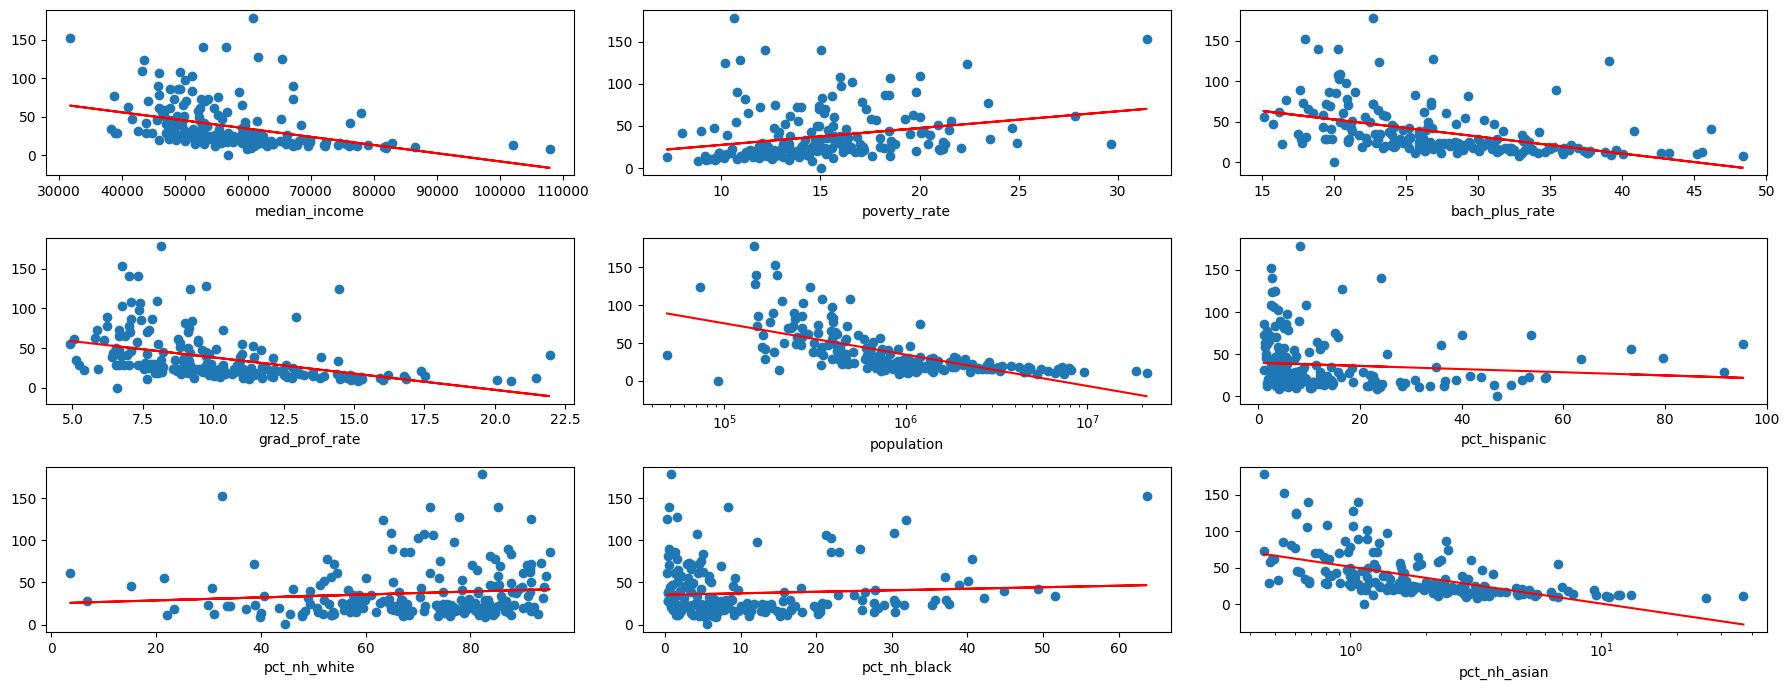

In [17]:
import matplotlib.pyplot as plt

x_vars = ['median_income', 'poverty_rate', 'bach_plus_rate', 'grad_prof_rate', 
          'population', 'pct_hispanic', 'pct_nh_white', 'pct_nh_black', 'pct_nh_asian']
y_var = 'search_interest'
log_vars = ['population', 'pct_nh_asian']

fig, axes = plt.subplots(3, 3, figsize=(18, 7))

for ax, x_var in zip(axes.flat, x_vars):
    # remove rows with empty values
    df_clean = combined_census_search_df[[x_var, y_var]].dropna()
    
    if len(df_clean) < 2:
        ax.set_xlabel(x_var)
        continue
    
    x, y = df_clean[x_var], df_clean[y_var]
    ax.scatter(x, y)
    
    # Make the regression lines
    if x_var in log_vars:
        ax.set_xscale('log')
        m, b = np.polyfit(np.log(x), y, 1)
        x_sorted = np.sort(x)
        ax.plot(x_sorted, m*np.log(x_sorted) + b, 'r-')
    else:
        m, b = np.polyfit(x, y, 1)
        ax.plot(x, m*x + b, 'r-')
    
    ax.set_xlabel(x_var)

plt.tight_layout()
plt.show()

### Counterintuitive findings

The plot above already appears to show some interesting, unexpected findings. Three factors stand out in particular: median income, poverty rate, and educational attainment.

As the 2019 median income of a DMA goes up, future search interest in AI for schoolwork goes down. As 2019 poverty rate goes up, future search interest goes up. There is also a negative correlation between the percentage of people with bachelor's degrees or higher and future interest.

In addition, in areas with higher populations (typically more urban, and often better connected to media and new technological trends), search interest in AI for school is lower than in smaller-population areas.

While the simple regression lines don't appear to fully represent the data trends, these early findings suggest that pre-AI communities that were more disadvantaged socioeconomically or educationally have shown higher levels of interest in AI for schoolwork in the post-AI era than more privileged communities.

**Hypothesis going forward**

These initial findings motivate a hypothesis to investigate further as the notebook proceeds: that socioeconomic and educational disadvantage in the pre-ChatGPT era led to strong post-ChatGPT search interest in using the new tools for schoolwork.

### Add educational achievement data

To further investigate educational attainment as a factor, the next step adds data on student scores to check for correlations between pre-AI educational achievement and post-AI search interest. The data come from the Educational Opportunity Project at Stanford University, documented in the Stanford Education Data Archive (SEDA) (Reardon et al., 2025). According to the project, SEDA contains "a range of detailed data on educational conditions, contexts, and outcomes in school districts and counties across the United States. It includes measures of academic achievement and achievement gaps for school districts and counties, as well as district-level measures of racial and socioeconomic composition, racial and socioeconomic segregation patterns, and other features of the schooling system" (Stanford Educational Opportunity Project, n.d.).

The SEDA data span 2009-2019 at county level. The data are filtered to 2019, and the crosswalk file is used again to convert county-level geography to DMA units.

### Download the SEDA data

The data are downloaded directly from Stanford's website using `requests`, then filtered to 2019.

In [144]:
import requests

url = "https://stacks.stanford.edu/file/druid:cs829jn7849/seda_county_long_gcs_5.0.csv"
response = requests.get(url)
response.raise_for_status()  # check for HTTP errors

with open("seda_county_long_gcs_5.0.csv", "wb") as f:
    f.write(response.content)

# Reduce it to a dataframe of only the year 2019 data, my target year for analysis
seda_all_years = pd.read_csv("seda_county_long_gcs_5.0.csv")
seda_df = seda_all_years[seda_all_years['year']==2019]
seda_df.to_csv("seda_county_long_gcs_5.0.csv")

print(f"Dataframe reduced to 2019 data, removing {len(seda_all_years) - len(seda_df)} rows.\n")
print("2019 data saved to seda_county_long_gcs_5.0.csv")

Dataframe reduced to 2019 data, removing 322889 rows.

2019 data saved to seda_county_long_gcs_5.0.csv


### Inspect the data

The features in the dataset are inspected next.

In [137]:
print("ROW COUNT:")
print(len(seda_df), "\n")
print("COLUMN COUNT:")
print(seda_df.shape[1], "\n")
print("COLUMN NAMES:")
print(seda_df.columns.tolist(), "\n")
print("PREVIEW:")
seda_df.head()

ROW COUNT:
32060 

COLUMN COUNT:
55 

COLUMN NAMES:
['fips', 'stateabb', 'sedacounty', 'sedacountyname', 'subject', 'grade', 'year', 'gcs_mn_all', 'gcs_mn_se_all', 'tot_asmt_all', 'gcs_mn_asn', 'gcs_mn_se_asn', 'tot_asmt_asn', 'gcs_mn_blk', 'gcs_mn_se_blk', 'tot_asmt_blk', 'gcs_mn_ecd', 'gcs_mn_se_ecd', 'tot_asmt_ecd', 'gcs_mn_fem', 'gcs_mn_se_fem', 'tot_asmt_fem', 'gcs_mn_hsp', 'gcs_mn_se_hsp', 'tot_asmt_hsp', 'gcs_mn_mal', 'gcs_mn_se_mal', 'tot_asmt_mal', 'gcs_mn_mfg', 'gcs_mn_se_mfg', 'tot_asmt_mfg', 'gcs_mn_nam', 'gcs_mn_se_nam', 'tot_asmt_nam', 'gcs_mn_nec', 'gcs_mn_se_nec', 'tot_asmt_nec', 'gcs_mn_neg', 'gcs_mn_se_neg', 'tot_asmt_neg', 'gcs_mn_wag', 'gcs_mn_se_wag', 'tot_asmt_wag', 'gcs_mn_wbg', 'gcs_mn_se_wbg', 'tot_asmt_wbg', 'gcs_mn_whg', 'gcs_mn_se_whg', 'tot_asmt_whg', 'gcs_mn_wht', 'gcs_mn_se_wht', 'tot_asmt_wht', 'gcs_mn_wng', 'gcs_mn_se_wng', 'tot_asmt_wng'] 

PREVIEW:


,fips,stateabb,sedacounty,sedacountyname,subject,grade,year,gcs_mn_all,gcs_mn_se_all,tot_asmt_all,...,tot_asmt_wbg,gcs_mn_whg,gcs_mn_se_whg,tot_asmt_whg,gcs_mn_wht,gcs_mn_se_wht,tot_asmt_wht,gcs_mn_wng,gcs_mn_se_wng,tot_asmt_wng
20,1,AL,1001,Autauga County,mth,3,2019,2.837842,0.187709,658,...,603.0,NaN,NaN,NaN,3.512545,0.219217,422.0,NaN,NaN,NaN
21,1,AL,1001,Autauga County,rla,3,2019,3.476377,0.217840,655,...,603.0,NaN,NaN,NaN,4.336632,0.260705,422.0,NaN,NaN,NaN
42,1,AL,1001,Autauga County,mth,4,2019,3.681330,0.158087,771,...,699.0,1.592767,0.576882,510.0,4.319517,0.186138,482.0,NaN,NaN,NaN
43,1,AL,1001,Autauga County,rla,4,2019,4.396111,0.183426,765,...,695.0,1.558444,0.722150,506.0,5.190803,0.206851,478.0,NaN,NaN,NaN
64,1,AL,1001,Autauga County,mth,5,2019,4.173987,0.152716,753,...,688.0,2.350984,0.649942,530.0,4.791158,0.174635,505.0,NaN,NaN,NaN


At 55 columns, this is a substantial feature set. Not all of them are used in the final analyses: the level of detail is too granular in many cases (for example, very specific gaps and scores per individual grade level).

The number of NaNs or empty strings per column is counted next.

In [142]:
print("Number of NaNs or empty strings per column:")
print((seda_df.isna() | (seda_df == '')).sum().to_string())

Number of NaNs or empty strings per column:
fips                  0
stateabb              0
sedacounty            0
sedacountyname        0
subject               0
grade                 0
year                  0
gcs_mn_all            0
gcs_mn_se_all         0
tot_asmt_all          0
gcs_mn_asn        26335
gcs_mn_se_asn     26335
tot_asmt_asn      26335
gcs_mn_blk        18671
gcs_mn_se_blk     18671
tot_asmt_blk      18671
gcs_mn_ecd         1726
gcs_mn_se_ecd      1726
tot_asmt_ecd       1726
gcs_mn_fem         1879
gcs_mn_se_fem      1879
tot_asmt_fem       1879
gcs_mn_hsp        16696
gcs_mn_se_hsp     16696
tot_asmt_hsp      16696
gcs_mn_mal         1849
gcs_mn_se_mal      1849
tot_asmt_mal       1849
gcs_mn_mfg         2422
gcs_mn_se_mfg      2422
tot_asmt_mfg       2422
gcs_mn_nam        28819
gcs_mn_se_nam     28819
tot_asmt_nam      28819
gcs_mn_nec         3742
gcs_mn_se_nec      3742
tot_asmt_nec       3742
gcs_mn_neg         4742
gcs_mn_se_neg      4742
tot_asmt_neg       4

Many features have a large number of missing values. The high-level features (overall ELA and math scores, for example) have zero missing. Only features without any missing values are used going forward. They are also the values of most interest in this study, as they are general and provide broader insights.

### Combine SEDA data into DMA table

The DMA table is enriched next with aggregates of county SEDA scores, with population-weighted means computed. The same crosswalk file used above maps county to DMA.

Some minor feature engineering is performed as well — for example, grouping scores by grade to represent grade-level scores as a feature per DMA.

As noted above, only the high-level SEDA features (which have no missing values) are used.

In [7]:
import re

# Function to normalize/clean FIPS codes
def norm_fips(x):
    if pd.isna(x): return pd.NA
    s = re.sub(r"\D", "", str(x))
    return s[-5:].zfill(5) if len(s) >= 4 else pd.NA

# Function to normalize/clean subject names
def normalize_subject(s):
    return {'mth':'math', 'rla':'ela'}.get(str(s).strip().lower(), str(s).strip().lower())

# Function to normalize/clean grade levels
def normalize_grade(g):
    m = re.search(r'\d+', str(g)) if not pd.isna(g) else None
    return int(m.group(0)) if m else np.nan

combined_data = combined_census_search_df.copy()

# fix subject and DMA name
combined_data['dma_name'] = combined_data['dma_name'].astype('string')
seda_df['subject'] = seda_df['subject'].apply(normalize_subject)

# Find county column and normalize
county_col = next((c for c in ['sedacounty','fips'] if c in seda_df.columns), None)
if not county_col:
    raise ValueError("No county column ")
seda_df['county_fips'] = seda_df[county_col].apply(norm_fips).astype('string')
seda_df['grade'] = seda_df['grade'].apply(normalize_grade)
seda_df = seda_df[['county_fips','subject','grade','gcs_mn_all','tot_asmt_all']].dropna(subset=['county_fips'])

# Crosswalk mapping FIPS to DMA names
xw = crosswalk_df[['FIPS','GOOGLE_DMA']].drop_duplicates()
xw['FIPS'] = xw['FIPS'].astype('string').str.zfill(5)

# merge and aggregate everything
sdc = seda_df.merge(xw.rename(columns={'FIPS':'county_fips','GOOGLE_DMA':'dma_name'}), on='county_fips')
sdc[['gcs_mn_all','tot_asmt_all']] = sdc[['gcs_mn_all','tot_asmt_all']].apply(pd.to_numeric, errors='coerce')
sdc['weighted_score'] = sdc['gcs_mn_all'] * sdc['tot_asmt_all']

# overall scoring
overall = (sdc.groupby(['dma_name','subject'])
           .agg(num=('weighted_score','sum'), den=('tot_asmt_all','sum'))
           .assign(score=lambda x: x['num']/x['den']).reset_index()
           .pivot(index='dma_name', columns='subject', values='score')
           .add_prefix('score_all_').reset_index())

# grade-level specific scores  
grade = (sdc.groupby(['dma_name','subject','grade'])
         .agg(num=('weighted_score','sum'), den=('tot_asmt_all','sum'))
         .assign(score=lambda x: x['num']/x['den']).reset_index()
         .pivot(index='dma_name', columns=['subject','grade'], values='score'))

grade.columns = [f"score_all_{subj}_g{int(gr) if not pd.isna(gr) else 'NA'}" for subj, gr in grade.columns]
grade = grade.reset_index()

wide_all = pd.merge(overall, grade, on='dma_name', how='outer')
combined_data = combined_data.merge(wide_all, on='dma_name', how='left')

combined_data.to_csv("combined_data.csv", index=False)
print(f"Saved the new DMA table to combined_data.csv")

Saved the new DMA table to combined_data.csv


### Inspect the final dataset yielded

Each column is checked for its percentage of missing values, and the first few entries of the dataset are previewed.

In [18]:
print("Missing values summary (NaN or empty string):\n",
      (combined_data.apply(lambda c: c.isna() | (c.astype(str).str.strip() == ''))
       .mean().mul(100).to_frame('Missing %')), "\n")
combined_data.head()

Missing values summary (NaN or empty string):
                    Missing %
dma_name            0.000000
median_income       0.000000
poverty_rate        0.000000
bach_plus_rate      0.000000
grad_prof_rate      0.000000
population          0.000000
dma_race_total      0.000000
pct_hispanic        0.000000
pct_nh_white        0.000000
pct_nh_black        0.000000
pct_nh_aian         0.000000
pct_nh_asian        0.000000
pct_nh_nhpi         0.000000
pct_nh_sor          0.000000
pct_nh_two_plus     0.000000
search_interest     4.784689
score_all_ela       4.306220
score_all_math      3.827751
score_all_ela_g5    4.784689
score_all_ela_g6    4.784689
score_all_ela_g7    5.741627
score_all_ela_g8    5.741627
score_all_math_g3   3.827751
score_all_math_g4   4.306220
score_all_math_g5   4.306220
score_all_math_g6   4.306220
score_all_ela_g3   11.961722
score_all_ela_g4   12.440191
score_all_math_g7  20.574163
score_all_math_g8  22.966507 



,dma_name,median_income,poverty_rate,bach_plus_rate,grad_prof_rate,population,dma_race_total,pct_hispanic,pct_nh_white,pct_nh_black,...,score_all_ela_g7,score_all_ela_g8,score_all_math_g3,score_all_math_g4,score_all_math_g5,score_all_math_g6,score_all_ela_g3,score_all_ela_g4,score_all_math_g7,score_all_math_g8
0,Abilene-Sweetwater TX,49829.716854,14.861864,20.185203,6.430317,313354.0,313354.0,25.408643,65.133044,6.056728,...,6.018851,6.797619,3.078998,3.832349,4.722895,5.893328,NaN,NaN,NaN,NaN
1,Albany GA,41566.266260,24.698772,15.674557,6.582405,410802.0,410802.0,7.486088,51.211289,38.897571,...,6.032529,6.966932,2.597806,3.239050,4.310031,4.764191,2.187345,3.113504,5.828063,7.098437
2,Albany-Schenectady-Troy NY,66079.485631,10.996812,33.698747,15.153370,1384057.0,1384057.0,5.047263,83.150838,5.533587,...,7.131027,8.129352,2.991960,3.683812,5.102112,5.858105,3.618677,4.530583,7.069254,7.944026
3,Albuquerque-Santa Fe NM,51503.275100,18.484042,27.672757,12.120732,1948465.0,1948465.0,43.818031,38.966879,1.642524,...,4.678661,5.148732,1.449883,2.363316,2.985258,4.557657,1.428249,2.636357,4.582965,NaN
4,Alexandria LA,45760.643206,19.797884,17.544143,6.197463,243625.0,243625.0,4.371883,65.060236,25.741201,...,6.451300,7.375815,1.792746,2.810956,3.731248,5.230513,1.803019,3.043710,6.185661,6.944554


The dataset has sufficient coverage in all columns, particularly the critical high-level information about income, racial composition, degree levels, and overall ELA and math scores.

The analysis and predictive modelling can now proceed on this dataset.

### Identifying important predictors with OLS

OLS regression is used next to control for other variables via multiple linear regression and to inspect the coefficients. For this initial exploration, missing values are handled by mean imputation. While this is not ideal, it avoids losing data that may be biased toward a particular type of DMA (for example smaller ones, where data is less easily collected).

The output is an adjusted $R^2$ and a ranked table of coefficients and p-values.

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Using all features as predictors, as a starting point (will likely reduce later)
predictors_all = ['median_income', 'poverty_rate', 'bach_plus_rate',
'grad_prof_rate', 'population', 'pct_hispanic',
'pct_nh_white', 'pct_nh_black', 'pct_nh_aian', 'pct_nh_asian',
'pct_nh_nhpi', 'pct_nh_sor', 'pct_nh_two_plus',
'score_all_ela', 'score_all_math',
'score_all_ela_g5', 'score_all_ela_g6', 'score_all_ela_g7',
'score_all_ela_g8', 'score_all_math_g3', 'score_all_math_g4',
'score_all_math_g5', 'score_all_math_g6', 'score_all_ela_g3',
'score_all_ela_g4', 'score_all_math_g7', 'score_all_math_g8']

def do_ols_calculation(predictors):
    needed_cols = ['search_interest'] + predictors
    
    # Mean imputation
    imputer = SimpleImputer(strategy='mean')
    data_imputed = combined_data[needed_cols].copy()
    data_imputed[needed_cols] = imputer.fit_transform(data_imputed[needed_cols])
    clean_idx = data_imputed.index

    target = data_imputed.loc[clean_idx, 'search_interest']
    features = data_imputed.loc[clean_idx, predictors]

    # Standardize the predictors
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    X_scaled_df = pd.DataFrame(X_scaled, index=clean_idx, columns=predictors)

    # collinearity check
    if np.linalg.matrix_rank(X_scaled) < X_scaled.shape[1]:
        print("Uh oh - Perfect multicollinearity found\n")

    # Add the intercept and fit OLS
    X_scaled_df = sm.add_constant(X_scaled_df)
    ols_results = sm.OLS(target, X_scaled_df).fit()

    regression_summary = ols_results.summary2().tables[1].copy()
    regression_summary['Abs_Coefficient'] = regression_summary['Coef.'].abs()
    ranked_predictors = (regression_summary
                .drop(index='const')
                .sort_values('Abs_Coefficient', ascending=False)
                [['Coef.', 'P>|t|', 'Abs_Coefficient']]
                .rename(columns={'Coef.': 'Coefficient', 'P>|t|': 'P-Value'}))
    ranked_predictors['P-Value'] = ranked_predictors['P-Value'].apply(lambda x: f"{x:.5f}")

    print(f"Adjusted R-squared: {ols_results.rsquared_adj:.3f}\n")
    print("Ranked Predictors:\n", ranked_predictors)

do_ols_calculation(predictors_all)

Uh oh - Perfect multicollinearity found

Adjusted R-squared: 0.253

Ranked Predictors:
                    Coefficient  P-Value  Abs_Coefficient
bach_plus_rate      -20.435470  0.01257        20.435470
median_income        12.429456  0.08162        12.429456
score_all_ela_g8     -9.875602  0.20807         9.875602
score_all_ela_g3      9.807549  0.25023         9.807549
score_all_ela_g7      7.651437  0.43058         7.651437
score_all_ela        -7.651379  0.15983         7.651379
score_all_ela_g6      6.519350  0.55414         6.519350
score_all_math_g5    -6.409156  0.58479         6.409156
score_all_math_g4     6.084399  0.60830         6.084399
pct_nh_asian         -5.722500  0.29697         5.722500
poverty_rate          5.696126  0.32156         5.696126
score_all_math_g8    -4.810920  0.36281         4.810920
grad_prof_rate        4.772425  0.51822         4.772425
pct_nh_sor           -4.625147  0.05286         4.625147
score_all_ela_g4     -4.150320  0.63715         4.150320


### Preliminary interpretation

The highest predictive variables are degree attainment levels, income, and ELA scores for various grade levels. Poverty rate and Asian percentage also reach high levels. In terms of statistical significance, the most notable is bachelor-or-higher rates.

The model also raised a multicollinearity warning. For the per-grade scores, it is possible that, due to multicollinearity, the grade-level scores are simply adding noise, as they are already cumulatively represented in the overall scores. These may be excluded in further analyses.

### Running it with fewer features

The OLS is now re-run with a curated list of features that excludes grade-specific scores. This should help reduce noise and multicollinearity.

In [28]:
predictors_reduced = [
    'median_income', 'poverty_rate', 'bach_plus_rate', 'grad_prof_rate',
    'pct_hispanic', 'pct_nh_white', 'pct_nh_black',
    'pct_nh_asian', 'pct_nh_two_plus', 'population',
    'score_all_ela', 'score_all_math', 'pct_nh_nhpi', 'pct_nh_sor']

do_ols_calculation(predictors_reduced)

Adjusted R-squared: 0.225

Ranked Predictors:
                  Coefficient  P-Value  Abs_Coefficient
pct_nh_white      -32.524391  0.14098        32.524391
pct_hispanic      -32.168246  0.10776        32.168246
bach_plus_rate    -21.909636  0.00424        21.909636
pct_nh_black      -18.529109  0.18444        18.529109
pct_nh_asian      -14.727285  0.02250        14.727285
median_income      12.379459  0.08092        12.379459
grad_prof_rate      7.369561  0.29081         7.369561
poverty_rate        4.943677  0.38030         4.943677
pct_nh_sor         -4.314894  0.07018         4.314894
population         -3.416808  0.23290         3.416808
pct_nh_two_plus    -3.218726  0.54307         3.218726
pct_nh_nhpi         2.492294  0.58523         2.492294
score_all_ela       1.785259  0.59134         1.785259
score_all_math      1.399467  0.68082         1.399467


In this second analysis, with fewer features, there is no multicollinearity warning. Here, racial factors lead the predictive coefficients. This list also emphasizes variables related to racial composition while retaining emphasis on the bachelor-or-higher rate and income. As before, ELA score appears as an important factor, although its weight is reduced here.

Multicollinearity is likely still an issue, despite the lack of explicit warning, because the racial percentages add up to 100 and are therefore inherently dependent on each other. Lasso regression is used next in an attempt to circumvent this.

### Lasso regression

To understand relative feature importance better, Lasso regression is used next: it may filter out some collinear features by reducing them to zero through its L1 penalty. It is not a full solution, but it brings us closer to identifying the truly important features.

In [ ]:
from sklearn.linear_model import LassoCV

def run_lasso(predictors):
    needed_cols = ['search_interest'] + predictors

    # Mean imputation, as before
    imputer = SimpleImputer(strategy='mean')
    data_imputed = combined_data[needed_cols].copy()
    data_imputed[needed_cols] = imputer.fit_transform(data_imputed[needed_cols])
                                                                   
    target = data_imputed["search_interest"]
    features = data_imputed[predictors]

    # Standardize the predictors
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    X_scaled_df = pd.DataFrame(X_scaled, columns=predictors, index=features.index)

    # fit LassoCV
    lasso_cv = LassoCV(cv=5, random_state=42)
    lasso_cv.fit(X_scaled_df, target)

    coeffs = pd.Series(lasso_cv.coef_, index=predictors)
    selected = coeffs[coeffs != 0].sort_values(ascending=False)

    print(selected.to_frame(name="Coefficient"))

run_lasso(predictors_all)


                Coefficient
pct_nh_aian        0.154213
pct_nh_sor        -0.949982
pct_nh_asian      -1.021759
population        -2.786228
bach_plus_rate    -7.929042


### Interpretation

This result now includes the population level as an important factor. As before, racial composition appears important, as does education level.

Notably, `pct_nh_aian` (the percentage of people who are American Indian or Alaskan Native) leads the coefficients. This is particularly surprising, considering the National Center for Education Statistics found that this exact demographic is strongly affected by the digital divide, with only 56% of AIAN students even having stable broadband internet access (National Center for Education Statistics, 2018). The fact that this group is a leading predictor of search interest in AI schoolwork tools is intriguing and further suggests that the findings of this study are likely to be counterintuitive and novel.

Interestingly, no specific grade levels appear on this list, supporting the view that those variables only add noise and multicollinearity. This also makes sense intuitively: students of various grade levels might use or be interested in AI tools for schoolwork, so the overall scores (rather than grade-specific) better capture general interest. Excluding grade-specific data does, however, prevent us from understanding potential differences in interest *between* grade levels — but that is not the purpose of this study. The aim is to analyze the predictive value of pre-AI socioeconomic circumstances in general relative to average interest trends in the post-AI era.

### Re-running Lasso without grade-level data

The Lasso analysis is now re-run without grade-level data.

In [ ]:
run_lasso(predictors_reduced)

                Coefficient
pct_nh_sor        -1.084524
pct_nh_asian      -1.121039
population        -2.868413
bach_plus_rate    -8.003646


While this result differs from the previous one, the analyses are coalescing around a particular set of factors. Racial composition appears consistently as a strong predictor, alongside bachelor-or-higher attainment, with ELA scores also showing as important earlier. Population size has likewise emerged as an important factor, as has median income.

Although it would be tempting to explore anomalies like `pct_nh_aian` further, we are hesitant to put strong weight on it. That factor, along with `pct_nh_sor` (percentage of people of 'other', non-specified races), might not properly describe more general trends since those two groups together represent an extremely small share of the US population (U.S. Census Bureau, 2020).

### Bootstrap LASSO analysis

A bootstrap analysis of Lasso regression is performed next to better understand the stability and reliability of different features. 1000 iterations are run with replacement, yielding confidence intervals and selection probabilities for each factor. This shows which factors are consistently picked by Lasso across resamples, providing a more robust view of importance.

In [ ]:
from sklearn.utils import resample
from tqdm import tqdm

def bootstrap_lasso_analysis(predictors, n_bootstrap):
    y = combined_data['search_interest']
    X = combined_data[predictors]
    
    # Impute same as before
    imputer = SimpleImputer(strategy='mean')
    data_imputed = pd.DataFrame(imputer.fit_transform(combined_data[['search_interest'] + predictors]), 
                              columns=['search_interest'] + predictors)
    
    y_clean = data_imputed['search_interest']
    X_scaled = StandardScaler().fit_transform(data_imputed[predictors])
    X_scaled_df = pd.DataFrame(X_scaled, columns=predictors)
    
    # Fit original model
    lasso_orig = LassoCV(cv=5, random_state=42, max_iter=2000)
    lasso_orig.fit(X_scaled_df, y_clean)
    
    # Bootstrap
    bootstrap_coeffs = []
    for i in tqdm(range(n_bootstrap)):
        boot_idx = resample(range(len(y_clean)), random_state=i)
        lasso_boot = LassoCV(cv=3, random_state=i, max_iter=2000)
        lasso_boot.fit(X_scaled_df.iloc[boot_idx], y_clean.iloc[boot_idx])
        bootstrap_coeffs.append(lasso_boot.coef_)
    
    bootstrap_coeffs = np.array(bootstrap_coeffs)
    
    # Calculate results
    results = []
    for i, var in enumerate(predictors):
        orig_coef = lasso_orig.coef_[i]
        boot_dist = bootstrap_coeffs[:, i]
        
        results.append({
            'Variable': var,
            'Coefficient': orig_coef,
            'Selection_Prob': np.mean(np.abs(boot_dist) > 1e-10),
            'CI_95': [np.percentile(boot_dist, 2.5), np.percentile(boot_dist, 97.5)]
        })
    
    return pd.DataFrame(results).sort_values('Selection_Prob', ascending=False)

bootstrap_lasso_analysis(predictors_reduced, 1000)

100%|██████████| 1000/1000 [00:26<00:00, 38.21it/s]


,Variable,Coefficient,Selection_Prob,CI_95
2,bach_plus_rate,-8.003646,0.980,"[-25.6591460951973, -0.5664958750918311]"
9,population,-2.868413,0.957,"[-10.73987487698133, 0.0]"
13,pct_nh_sor,-1.084524,0.813,"[-8.337516212178803, 0.0]"
7,pct_nh_asian,-1.121039,0.811,"[-19.958060301876206, 0.0]"
4,pct_hispanic,-0.000000,0.565,"[-35.11643331108933, 0.0]"
6,pct_nh_black,0.000000,0.481,"[-20.81092315816626, 5.433458531718316]"
1,poverty_rate,0.000000,0.413,"[-3.2091666894072057, 11.086751625363123]"
10,score_all_ela,-0.000000,0.392,"[-2.793314996641342, 5.08401004294137]"
11,score_all_math,0.000000,0.348,"[-1.7006057060047697, 5.313182075330469]"
3,grad_prof_rate,-0.000000,0.308,"[-4.658254493177617, 9.908409534676016]"


### Interpretation

This bootstrapping result confirms that the important factors are bachelor-or-higher rate, population size, racial composition (particularly Asian, Hispanic and Black), and ELA scores. Math scores and median income come in below those.

### Final selection of factors to dig into

Based on these analyses, the following factors are selected for further study:

- Median income
- Poverty rate
- Bachelor-or-higher attainment rate
- Graduate degree attainment rate
- Population size
- Asian percentage
- Black percentage
- Hispanic percentage
- White percentage

These factors appear consistently in the prior analyses as important and are also intuitively relevant to the research question. If pre-existing socioeconomic and educational conditions matter for interest in AI for schoolwork, these factors are highly likely to be important because they represent the core of American socioeconomic and educational conditions.

In [21]:
predictors_final = ['median_income', 'poverty_rate', 'bach_plus_rate', 'grad_prof_rate', 
'population', 'pct_hispanic', 'pct_nh_white', 'pct_nh_black', 'pct_nh_asian']

### Visualize relationships between these variables and search interest

A LOWESS regression line is plotted next over the log-transformed features vs search interest, to assess the key relationships. LOWESS captures relationships that may not be strictly linear, which the earlier straight regression lines did not fully match.

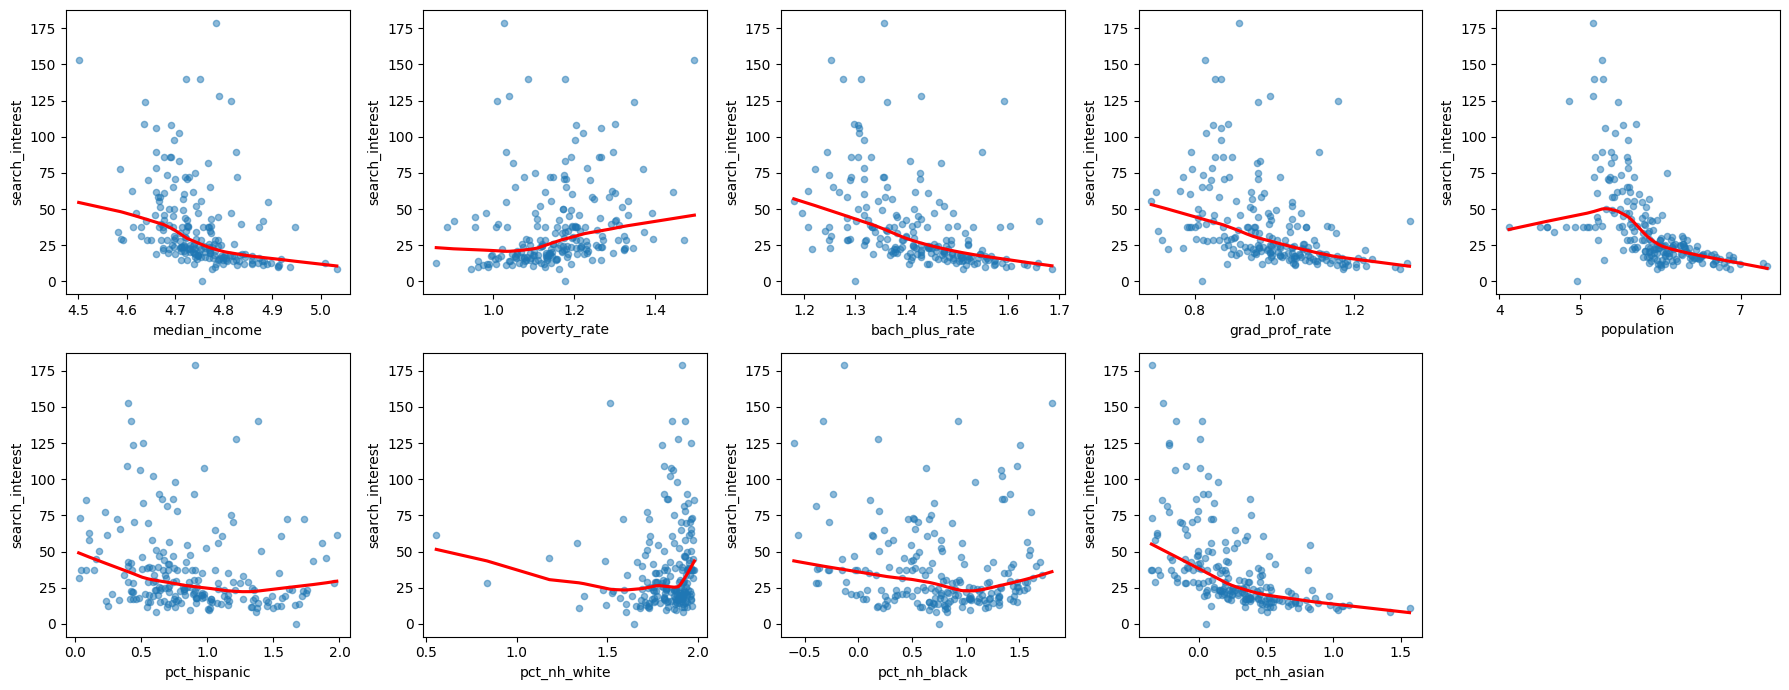

In [23]:
import seaborn as sns

data_imputed = pd.DataFrame(
    SimpleImputer(strategy='mean').fit_transform(combined_data[['search_interest'] + predictors_final]), 
    columns=['search_interest'] + predictors_final)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, col in enumerate(predictors_final):
    sns.regplot(x=np.log10(data_imputed[col]), y='search_interest', data=data_imputed, 
                lowess=True, scatter_kws={'alpha': 0.5, 's': 20}, 
                line_kws={'color': 'red'}, ax=axes.flat[i])

axes.flat[9].remove()
plt.tight_layout()
plt.show()

### Interpretation

The four clearest trends are for bachelor and graduate attainment, median income, and Asian percentage. Those plots reinforce the earlier observations: the higher a DMA's 2019 financial status and degree attainment, the lower its post-ChatGPT search interest in AI school tools. This is, again, quite counterintuitive: one might expect wealthier, better-educated population centers to be early adopters of technology and show the most interest in new trends. That does not appear to be the case here.

### Clustering

Next, DMAs are clustered based on the identified factors. This shows how search interest in AI-for-school differs across DMAs with varying 2019 socioeconomic conditions.

### Imputing missing values

K-means requires no NaNs. Most of the NaN problem has been resolved by the selection of final variables, but not entirely.

Since 9 DMAs are still missing a value for `score_all_ela`, this is imputed as the average of the given DMA's 10 nearest neighbors based on similarity across the other features.

In [7]:
from sklearn.neighbors import NearestNeighbors

df_for_clustering = combined_data.copy()

# Get rows with missing ELA
# Get complete rows (with all values for ELA + all predictors)
# The complete rows will be for comparison as nearest neighbors
missing_idx = df_for_clustering[df_for_clustering['score_all_ela'].isnull()].index
complete = df_for_clustering.dropna(subset=['score_all_ela'] + predictors_final)

# Find the 10 nearest neighbors
scaler = StandardScaler()
nn = NearestNeighbors(n_neighbors=10)
nn.fit(scaler.fit_transform(complete[predictors_final]))

# Impute missing values as mean of nearest neighbors
for idx in missing_idx:
    row = df_for_clustering.loc[[idx], predictors_final]
    _, neighbors = nn.kneighbors(scaler.transform(row))
    neighbor_scores = complete.iloc[neighbors[0]]['score_all_ela']
    df_for_clustering.loc[idx, 'score_all_ela'] = neighbor_scores.mean()

print("Data imputed for missing ELA scores")

Data imputed for missing ELA scores


### Finding the optimal K value

Before clustering, k = 1-50 is tested, measuring WCSS, distance between centroids, and silhouette score. This helps determine the optimal k value.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_for_clustering[predictors_final])

# Test k values 1-50
results = []
for k in range(1, 51):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate within-cluster sum of squares
    # Calculate centroid distance (AKA mean distance between centroids)
    # Calculate silhouette score
    wcss = kmeans.inertia_
    centroid_dist = np.mean(cdist(kmeans.cluster_centers_, kmeans.cluster_centers_))
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({'k': k, 'wcss': wcss, 'centroid_distance': centroid_dist, 'silhouette_score': sil_score})

k_means_test_df = pd.DataFrame(results)

print("Test results saved to k_means_test_df")
k_means_test_df

Test results saved to k_means_test_df


,k,wcss,centroid_distance,silhouette_score
0,1,1463.000000,0.000000,NaN
1,2,1145.318031,1.435244,0.340113
2,3,880.888942,2.349050,0.341513
3,4,677.962102,3.032608,0.374758
4,5,562.145137,4.789608,0.326445
5,6,487.535323,4.576351,0.280677
6,7,448.149508,4.693891,0.274175
7,8,417.145560,4.229355,0.256789
8,9,376.299679,4.415286,0.261149
9,10,357.366502,4.820196,0.260847


### Visualise the results of optimal K testing

The above results are now plotted.

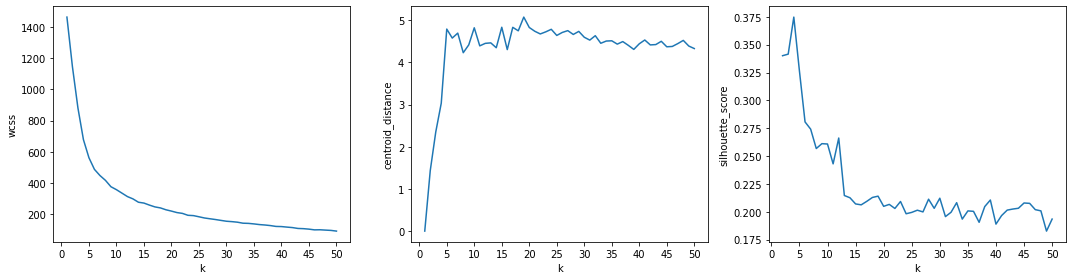

In [ ]:
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

k_vals = k_means_test_df['k'].values
intra_vals = k_means_test_df['wcss'].values
centroid_vals = k_means_test_df['centroid_distance'].values
silhouette_vals = k_means_test_df['silhouette_score'].values

axes[0].plot(k_vals, intra_vals)
axes[0].set_xlabel('k')
axes[0].set_ylabel('wcss')
axes[0].xaxis.set_major_locator(MultipleLocator(5))

axes[1].plot(k_vals, centroid_vals)
axes[1].set_xlabel('k')
axes[1].set_ylabel('centroid_distance')
axes[1].xaxis.set_major_locator(MultipleLocator(5))

axes[2].plot(k_vals, silhouette_vals)
axes[2].set_xlabel('k')
axes[2].set_ylabel('silhouette_score')
axes[2].xaxis.set_major_locator(MultipleLocator(5))

plt.tight_layout()
plt.show()

### Interpretation of optimal K test results

There is a clear optimal k around k=5. At this value, the within-cluster sum of squares plot shows the elbow bend, centroid distance levels off and stops improving, and the silhouette score peaks before declining.

## K-means clustering

All DMAs are now clustered using k=5, with cluster assignments saved back to the non-imputed dataframe so the subsequent analyses can proceed without the imputations.

In [ ]:
features = ['bach_plus_rate', 'score_all_ela', 'pct_nh_black', 'median_income', 
'pct_hispanic', 'pct_nh_asian', 'pct_nh_white']
X_scaled = StandardScaler().fit_transform(df_for_clustering[features])
labels = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled)

# Add cluster ids to the DMA table
cluster_map = dict(zip(df_for_clustering['dma_name'], labels))
combined_data['cluster_id'] = combined_data['dma_name'].map(cluster_map)

os.makedirs('../data/processed', exist_ok=True)
combined_data.to_csv('../data/processed/merged_dataset.csv')
print(f"Clusters: {combined_data['cluster_id'].value_counts().sort_index().to_dict()}")

Clusters: {0: 102, 1: 20, 2: 56, 3: 2, 4: 29}


### Plot clusters on US map

The DMAs are now plotted against a map of the United States, colored by their cluster assignment. This gives a sense of the geography of these clusters and any insights that might arise from it.

To do this, a GeoJSON containing DMA boundaries and centroid coordinates is downloaded. DMA naming conventions differ between datasets, so fuzzy matching (with a string-match score threshold of 80) is used to align names. Non-continental US DMAs are filtered out to keep the map visually readable. The DMA centroids are then plotted onto a US map sourced from Cartopy.

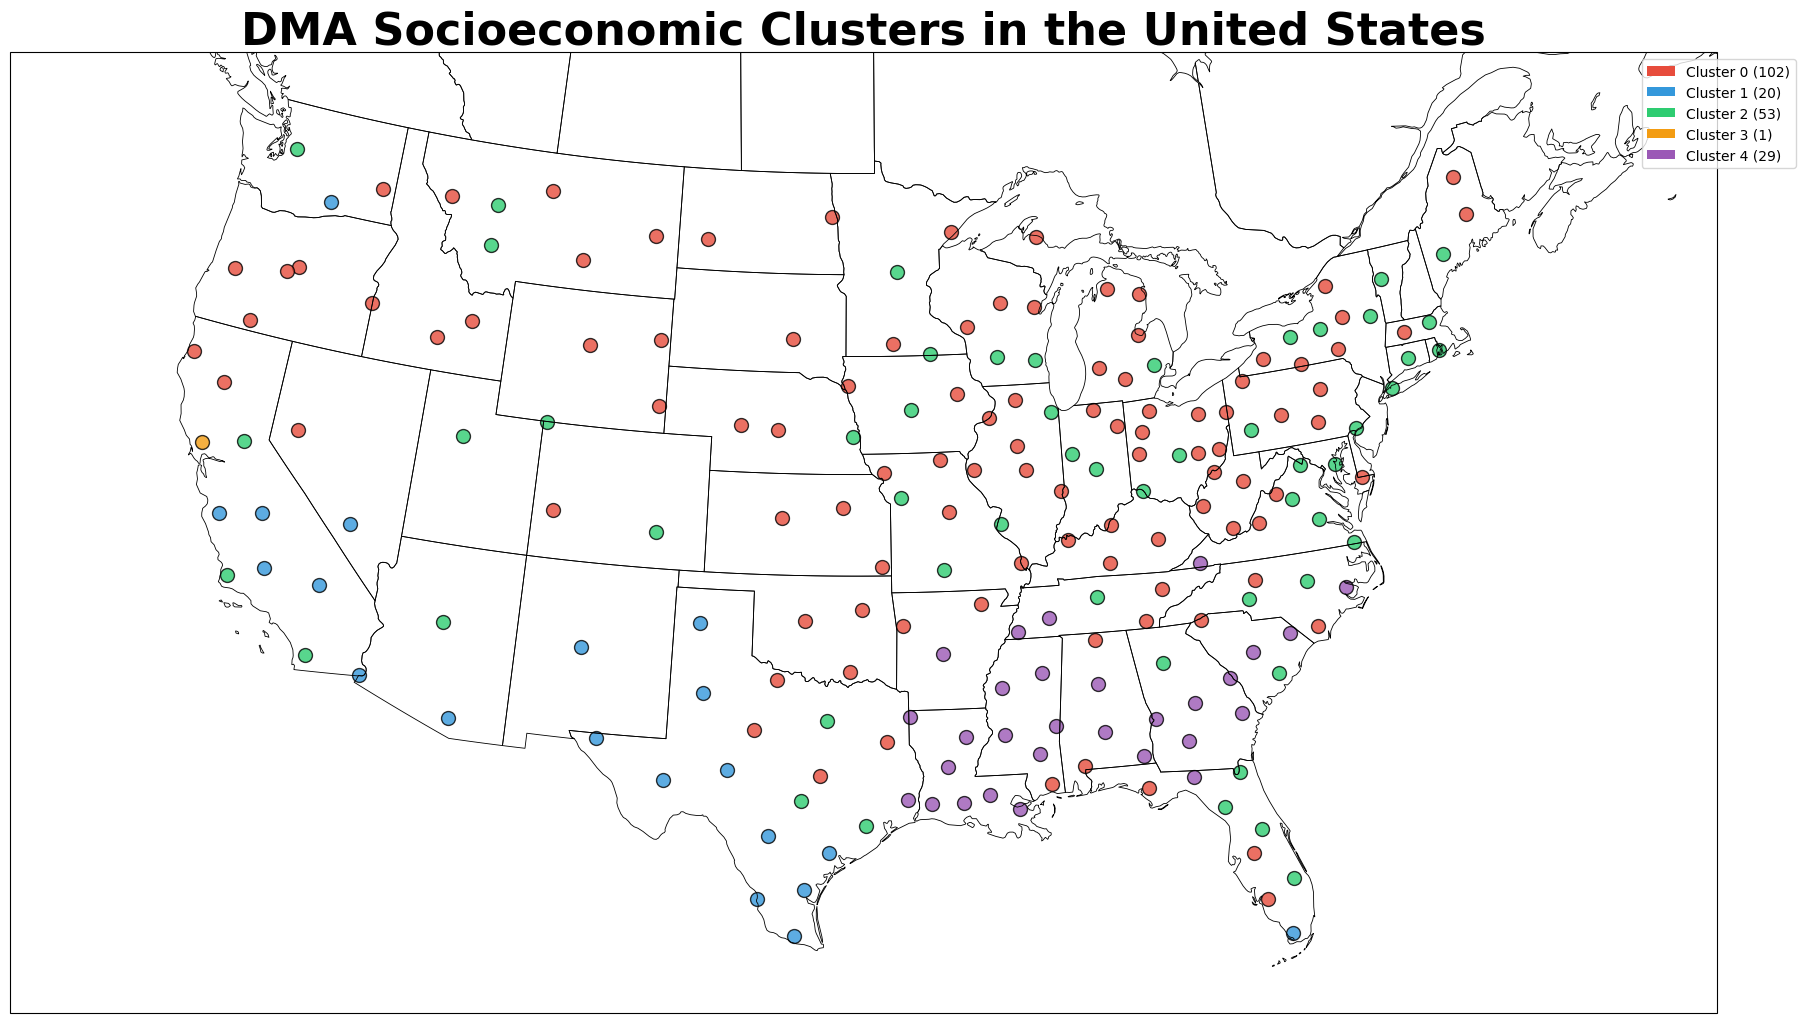

In [7]:
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch
from fuzzywuzzy import process


url_for_dma_data = 'https://raw.githubusercontent.com/simzou/nielsen-dma/master/nielsen-mkt-map.json'

def create_matched_csv(ai_data: pd.DataFrame, geojson_url: str) -> str:
    # load DMA reference boundaries
    dma_gdf = gpd.read_file(geojson_url)

    canonical_names = dma_gdf['dma_name'].astype(str).unique()

    # fuzzy match input DMA names against reference
    matched_names = {}
    for name in ai_data['dma_name'].astype(str).unique():
        match, score = process.extractOne(name, canonical_names)
        if score > 80:
            matched_names[name] = match

    # replace with matched names
    ai_data = ai_data.copy()
    ai_data['dma_name'] = ai_data['dma_name'].map(matched_names)
    ai_data = ai_data.dropna(subset=['dma_name'])

    output_path = 'ai_data_clustered_matched.csv'
    ai_data.to_csv(output_path, index=False)
    return output_path

def create_dma_cluster_map(
    data_path,
    geojson_url="https://raw.githubusercontent.com/simzou/nielsen-dma/master/nielsen-mkt-map.json"
):

    data = pd.read_csv(data_path)
    dma_gdf = gpd.read_file(geojson_url)

    # Merge and filter
    merged = dma_gdf.merge(data, on="dma_name", how="inner").dropna(
        subset=["latitude", "longitude"]
    )
    continental = merged[
        (merged["longitude"].between(-125, -66.5)) &
        (merged["latitude"].between(24, 50))
    ]

    fig, ax = plt.subplots(
        figsize=(18, 12),
        subplot_kw={"projection": ccrs.AlbersEqualArea(-96.0)}
    )
    ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(
        cfeature.STATES.with_scale("50m"),
        edgecolor="black",
        linewidth=0.6
    )

    colors = [
        "#E74C3C", "#3498DB", "#2ECC71", "#F39C12",
        "#9B59B6", "#1ABC9C", "#E67E22", "#34495E"
    ]

    # Plot all the clusters
    for cluster_id in sorted(continental["cluster_id"].unique()):
        cluster_data = continental[continental["cluster_id"] == cluster_id]
        ax.scatter(
            cluster_data["longitude"],
            cluster_data["latitude"],
            c=colors[int(cluster_id) % len(colors)],
            s=100,
            alpha=0.8,
            edgecolors="black",
            transform=ccrs.PlateCarree()
        )

    # create the legend to identify clusters
    legend_elements = [
        Patch(
            facecolor=colors[int(cid) % len(colors)],
            label=f"Cluster {cid} ({len(continental[continental['cluster_id'] == cid])})"
        )
        for cid in sorted(continental["cluster_id"].unique())
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1))

    ax.set_title(
        "DMA Socioeconomic Clusters in the United States",
        fontsize=32,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

data = pd.read_csv('../data/processed/merged_dataset.csv', index_col=0)

matched_file = create_matched_csv(data, url_for_dma_data)
create_dma_cluster_map(matched_file)

### Map interpretation

This map reveals 4 distinct groups (along with cluster 3, which only has one data point on the map and two total). In the south-east of the US, we find Cluster 4, which represents non-metropolitan Southern DMAs with markedly elevated Black population shares (mean Black share 33.7% vs national mean ~13%); we characterize this group as a Black-Belt-region non-metropolitan cluster rather than as 'predominantly Black', since the cluster mean is still majority non-Hispanic white. Similarly, in the south-west, we find Cluster 1, which includes border regions and presumably contains large Hispanic populations, including in the major cities of Southern California. Cluster 0 dominates rural areas and the so-called "Flyover States", which are predominantly lower-income, whiter, and more remote than the rest of the US. Finally, Cluster 2 represents major east coast and midwestern cities, and likely captures America's large non-California population centers like New York City, which are wealthier, better educated, and have higher populations than the rest of the US.

### Visualizing cluster data

The data are visualized next per feature to see how the clusters differ along each dimension.

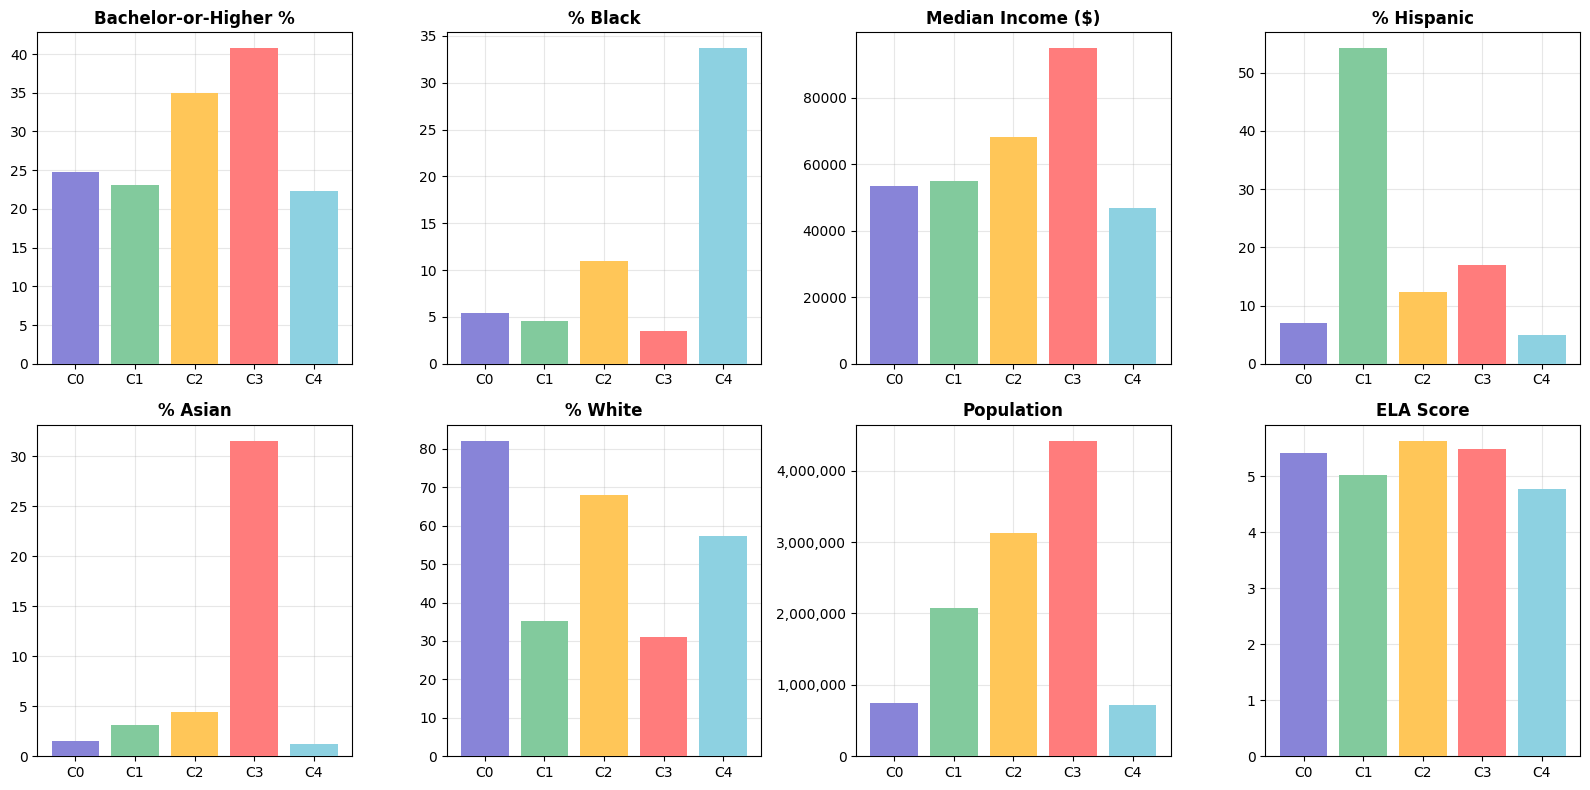

In [44]:
from matplotlib.ticker import FuncFormatter

vars_labels = {
    'bach_plus_rate': 'Bachelor-or-Higher %', 'pct_nh_black': '% Black', 
    'median_income': 'Median Income ($)', 'pct_hispanic': '% Hispanic',
    'pct_nh_asian': '% Asian', 'pct_nh_white': '% White',
    'population': 'Population', 'score_all_ela': 'ELA Score'
}

# Calculate cluster stats
stats = data.groupby('cluster_id')[list(vars_labels.keys())].mean()
 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
colors = ['#8884d8', '#82ca9d', '#ffc658', '#ff7c7c', '#8dd1e1']

for i, (var, label) in enumerate(vars_labels.items()):
    ax = axes[i]
    means = [stats.loc[j, var] for j in range(5)]
    
    ax.grid(True, alpha=0.3)
    bars = ax.bar(range(5), means, color=colors, zorder=3)
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(5))
    ax.set_xticklabels([f'C{j}' for j in range(5)])
    
    # Format population y-axis so it doesn't use scientific notation
    if var == 'population':
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## Analysis of cluster data

These data confirm the map-based reading. A more detailed interpretation of each cluster:

- Cluster 0 (102 DMAs): This cluster is overwhelmingly white (82%), lower income ($53,000/year), moderately educated (25% bachelor or higher), and contains some of the smallest population centers. Essentially, these are mostly small, rural, white communities.

- Cluster 1 (20 DMAs): This cluster is Hispanic-majority regions (54%) with low-to-moderate income ($55,000/year) and larger population centers (2 million average). It includes cities near the Mexican border and in Southern California.

- Cluster 2 (56 DMAs): This cluster is higher income ($68,000/year), more educated (35% bachelor or higher), and includes larger metropolitan areas (3 million average), particularly on the East Coast and Midwest.

- Cluster 3 (2 DMAs): This cluster only has 2 cities, San Francisco and Honolulu, but they have the highest income ($95,000/year), the most educated population (41% bachelor or higher), and the highest Asian population share (32%). It also contains the largest population centers on average (4.4 million average).

- Cluster 4 (29 DMAs): This cluster comprises non-metropolitan Southern DMAs in the Black Belt region, with markedly elevated Black population share (34% vs ~13% national) — though still majority non-Hispanic white at the cluster mean. It also has the lowest income ($47,000/year), lower education (22% bachelor-or-higher), and small population centers.

### Calculate average search interest per cluster

In [47]:
print("Average search interest for each cluster:")
print(data.groupby('cluster_id')['search_interest'].mean())

Average search interest for each cluster:
cluster_id
0    45.220470
1    40.884870
2    19.741763
3    11.200780
4    50.132308
Name: search_interest, dtype: float64


## Interpretation

This finding is striking. It suggests that the communities most disenfranchised nationally before ChatGPT — predominantly Black, predominantly Hispanic, very rural, poor, and less well educated — now show the highest number of searches for AI school help. Meanwhile, the wealthier, better educated, larger cities show much lower interest. This leads to an early conclusion, explored further below: AI may be perceived as a tool for accessibility by students. In other words, students may see it as an opportunity to diminish gaps, which is why its interest has become highest in places where gaps existed the most.

## Train a model to predict search interest

The next step trains a model to predict search interest using the selected variables, aiming for as much accuracy as possible.

#### Test different model types

As a starting point, several model types are tested and their $R^2$ scores compared before settling on one.

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

selected_features = ['bach_plus_rate', 'pct_nh_black', 'median_income', 
'pct_hispanic', 'pct_nh_asian', 'pct_nh_white', 'population', 'score_all_ela']
target_feature = 'search_interest'

# Prepare & split the data
X = SimpleImputer(strategy='mean').fit_transform(data[selected_features])
y = data[target_feature].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boost': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred)
    }

comparison_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("Model Comparison:")
print(comparison_df.round(4))

Model Comparison:
                    R²      MAE
Random Forest   0.5430  15.1256
Gradient Boost  0.4785  16.2035
Lasso           0.1676  23.3521
Ridge           0.1213  23.4439
Linear          0.1185  23.4515


### Random forest

Based on the promising random forest result above, a random forest model is now trained to predict search interest using the chosen variables. Grid search is used to tune hyperparameters.

In [8]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest using various hyperparameters
param_grid = {
        'n_estimators': [100, 200, 300],      # Total amount of of trees in forest
        'max_depth': [None, 10, 20, 30],      # Max depth for the tree
        'min_samples_split': [2, 5, 10],      # min of samples required to split a node
        'min_samples_leaf': [1, 2, 4]         # min number of samples needed at each leaf node
    }

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)

# Evaluate
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best parameters: {grid_search.best_params_}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
R-squared: 0.5056
MAE: 15.6885

Feature Importance:
          Feature  Importance
6      population    0.432072
4    pct_nh_asian    0.160558
2   median_income    0.134044
0  bach_plus_rate    0.120778
7   score_all_ela    0.044758
3    pct_hispanic    0.038831
1    pct_nh_black    0.035789
5    pct_nh_white    0.033170


### Interpretation

The best parameters found were `{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}`. This suggests that slightly shallower trees (`max_depth: 10`) requiring at least two samples in a leaf node perform better.

However, $R^2$ fell in this run, suggesting that the previously more promising score was not a proper representation of the predictive value of these variables.

## Gradient Boosting Model

A gradient boosting model with hyperparameter tuning via grid search is tried next. It also performed well in the initial testing, and a tuned version may give a stronger $R^2$ than random forest.

In [18]:
def gradient_boost_modelling(X_train):
    param_grid = {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }

    model = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"Best params: {model.best_params_}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"R²: {r2_score(y_test, y_pred):.4f}")

    gb_importance_df = pd.DataFrame({
        'Feature': selected_features,
        'Importance': model.best_estimator_.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(gb_importance_df)

selected_features = ['bach_plus_rate', 'pct_nh_black', 'median_income', 
'pct_hispanic', 'pct_nh_asian', 'pct_nh_white', 'population', 'score_all_ela']
target_feature = 'search_interest'

# Prepare & split the data
X = SimpleImputer(strategy='mean').fit_transform(data[selected_features])
y = data[target_feature].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gradient_boost_modelling(X_train)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
MAE: 15.0190
R²: 0.5473
          Feature  Importance
6      population    0.542291
0  bach_plus_rate    0.122562
4    pct_nh_asian    0.111120
2   median_income    0.079853
3    pct_hispanic    0.050709
1    pct_nh_black    0.041435
7   score_all_ela    0.037105
5    pct_nh_white    0.014926


### Interpretation

Gradient boosting exceeds the random forest on this single 80/20 split, and is a better predictive model. The single-split $R^2$ of 0.547 reported above is a useful upper-end reference, but at $n=209$ a single split is too sensitive to fold composition. Under 5-fold cross-validation with grid-searched hyperparameters, the same model achieves $R^2 = 0.42 \pm 0.12$ with mean absolute error $\approx 14.2$. The cross-validated 0.42 is the headline figure reported in the paper.

In terms of feature importance, the top four predictors combine population size, education level, race, and income; all four contribute meaningfully.

### Rerun with fewer variables

Since the white percentage and ELA scores are the least important of these variables, the model is now re-run without each, to see if performance improves.

In [ ]:
features_minus_white = ['bach_plus_rate','pct_nh_black','median_income',
'pct_hispanic','pct_nh_asian','population','score_all_ela']
target_feature = 'search_interest'

X2 = SimpleImputer(strategy='mean').fit_transform(data[features_minus_white])
y = data[target_feature].fillna(0)
X_train2, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

selected_features = features_minus_white
gradient_boost_modelling(X_train2)

print("\n==========\n")

features_minus_white_and_ela = ['bach_plus_rate','pct_nh_black','median_income',
'pct_hispanic','pct_nh_asian','population']
target_feature = 'search_interest'

X3 = SimpleImputer(strategy='mean').fit_transform(data[features_minus_white_and_ela])
y = data[target_feature].fillna(0)
X_train3, X_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

selected_features = features_minus_white_and_ela
gradient_boost_modelling(X_train3)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
MAE: 14.8805
R²: 0.5532
          Feature  Importance
5      population    0.550488
0  bach_plus_rate    0.124445
4    pct_nh_asian    0.114563
2   median_income    0.082964
3    pct_hispanic    0.047142
1    pct_nh_black    0.044096
6   score_all_ela    0.036302


Best params: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
MAE: 18.0985
R²: 0.3873
          Feature  Importance
5      population    0.629815
3    pct_hispanic    0.112752
0  bach_plus_rate    0.093281
2   median_income    0.087461
4    pct_nh_asian    0.050696
1    pct_nh_black    0.025995


### Interpretation

The model achieved an $R^2$ of over 0.55 in the 7-feature run, before declining to 0.38 in the 6-feature run.

This leads to the conclusion that the 7 predictive features are:

- Rate of people with bachelor's degrees or higher
- Median income
- Percentage of Black people
- Percentage of Hispanic people
- Percentage of Asian people
- Population size
- Average student scores on ELA tests

On a single 80/20 train-test split this model reports $R^2 \approx 0.547$. We retain that single-split number as a useful upper-end reference, but at $n=209$ a single split is too sensitive to fold composition. Under a more defensible 5-fold cross-validation protocol with grid-searched hyperparameters, the same model achieves $R^2 = 0.42 \pm 0.12$, with mean absolute error $\approx 14.2$. We adopt $R^2 \approx 0.42$ as the headline figure in the paper. It indicates that preexisting socioeconomic and educational conditions contributed greatly to student interest in using AI for schoolwork.

# Conclusion

See `paper/main.tex` for the full conclusion, including the summary of findings, the discussion of digital-divide and equitable-policy implications, the limitations of the study, and suggestions for future research.

# References

The full bibliography for citations referenced in this notebook is in `paper/refs.bib`, with the in-text rendering in the compiled paper (`paper/main.tex`).

## Additional analyses for the paper

The cells below were added during the final paper revision to support
specific claims:

- **Cluster geography verification** (Appendix B, Table tab:clusterverify)
- **Cluster 0 rurality thresholds** (used for the rural & small-metro label)
- **Variance inflation factors** (Appendix C, Table tab:vif)
- **Regenerated 4-panel LOWESS figure** (Figure 1, with median household
  income first and a clearer y-axis label)

These cells read from the final analytic dataset
(`data/processed/merged_dataset.csv`, also produced by the steps above)
and do not require any of the live API connections.

In [1]:
# Cluster geography verification (Appendix B)
DATA_PATH = "../data/processed/merged_dataset.csv"
SOUTH = {"AL", "AR", "FL", "GA", "KY", "LA", "MS", "NC",
         "SC", "TN", "VA", "WV", "TX", "OK"}
RACE_COLS = ["pct_hispanic", "pct_nh_white", "pct_nh_black", "pct_nh_asian"]


def get_state(name):
    parts = str(name).strip().split()
    return parts[-1] if parts and len(parts[-1]) == 2 and parts[-1].isupper() else ""


df = pd.read_csv(DATA_PATH, index_col=0)
df["state"] = df["dma_name"].apply(get_state)

print("=== Cluster geography (paper Appendix B, Table tab:clusterverify) ===")
for cid in sorted(df["cluster_id"].dropna().unique()):
    sub = df[df["cluster_id"] == cid]
    states = sub["state"].value_counts()
    south_share = sub["state"].isin(SOUTH).mean()
    print(f"\nCluster {int(cid)} (n={len(sub)}):")
    print(f"  Top states: {dict(states.head(7))}")
    print(f"  Southern share: {south_share:.0%}")
    print("  Racial means: " + ", ".join(
        f"{c}={sub[c].mean():.1f}" for c in RACE_COLS))

=== Cluster geography (paper Appendix B, Table tab:clusterverify) ===

Cluster 0 (n=102):
  Top states: {'OH': np.int64(7), 'MI': np.int64(6), 'NY': np.int64(5), 'IL': np.int64(5), 'OR': np.int64(4), 'MT': np.int64(4), 'WV': np.int64(4)}
  Southern share: 28%
  Racial means: pct_hispanic=7.0, pct_nh_white=82.1, pct_nh_black=5.4, pct_nh_asian=1.5

Cluster 1 (n=20):
  Top states: {'TX': np.int64(10), 'CA': np.int64(5), 'NM': np.int64(1), 'NV': np.int64(1), 'FL': np.int64(1), 'AZ': np.int64(1), 'WA': np.int64(1)}
  Southern share: 55%
  Racial means: pct_hispanic=54.2, pct_nh_white=35.1, pct_nh_black=4.6, pct_nh_asian=3.1

Cluster 2 (n=56):
  Top states: {'NY': np.int64(5), 'FL': np.int64(4), 'AK': np.int64(3), 'TX': np.int64(3), 'VA': np.int64(3), 'MO': np.int64(3), 'CA': np.int64(3)}
  Southern share: 27%
  Racial means: pct_hispanic=12.3, pct_nh_white=68.1, pct_nh_black=11.0, pct_nh_asian=4.4

Cluster 3 (n=2):
  Top states: {'HI': np.int64(1), 'CA': np.int64(1)}
  Southern share: 0%
  

In [2]:
# Cluster 0 rurality thresholds (paper Section 5.3 narrative)
print("=== Population thresholds by cluster ===")
print(f"National DMA median pop: {df['population'].median():,.0f}")
print(f"National DMA mean pop:   {df['population'].mean():,.0f}\n")
for cid in sorted(df["cluster_id"].dropna().unique()):
    sub = df[df["cluster_id"] == cid]
    print(f"Cluster {int(cid)} (n={len(sub)}):")
    print(f"  median pop = {sub['population'].median():,.0f}")
    print(f"  mean pop   = {sub['population'].mean():,.0f}")
    for thresh, label in [(500_000, '<500K'),
                          (1_000_000, '<1M'),
                          (2_500_000, '<2.5M')]:
        share = (sub['population'] < thresh).mean()
        print(f"  {label}: {share:.0%}")
    print()

=== Population thresholds by cluster ===
National DMA median pop: 760,534
National DMA mean pop:   1,542,248

Cluster 0 (n=102):
  median pop = 495,018
  mean pop   = 741,215
  <500K: 50%
  <1M: 74%
  <2.5M: 98%

Cluster 1 (n=20):
  median pop = 827,694
  mean pop   = 2,070,279
  <500K: 30%
  <1M: 55%
  <2.5M: 85%

Cluster 2 (n=56):
  median pop = 2,442,644
  mean pop   = 3,133,189
  <500K: 14%
  <1M: 27%
  <2.5M: 50%

Cluster 3 (n=2):
  median pop = 4,420,855
  mean pop   = 4,420,855
  <500K: 0%
  <1M: 0%
  <2.5M: 50%

Cluster 4 (n=29):
  median pop = 638,116
  mean pop   = 724,828
  <500K: 41%
  <1M: 79%
  <2.5M: 100%



In [3]:
# VIF for the seven supervised features (paper Appendix C, Table tab:vif)
from statsmodels.stats.outliers_influence import variance_inflation_factor

SUPERVISED = ["median_income", "bach_plus_rate", "population", "pct_hispanic",
              "pct_nh_black", "pct_nh_asian", "score_all_ela"]

X = df[SUPERVISED].copy()
X = X.fillna(X.mean())
Xz = (X - X.mean()) / X.std()

vifs = pd.DataFrame({
    "feature": SUPERVISED,
    "VIF": [variance_inflation_factor(Xz.values, i)
            for i in range(len(SUPERVISED))],
}).sort_values("VIF", ascending=False)
print("=== VIF (paper Appendix C, Table tab:vif, n=209) ===")
print(vifs.round(2).to_string(index=False))

=== VIF (paper Appendix C, Table tab:vif, n=209) ===
       feature  VIF
 median_income 4.18
bach_plus_rate 3.31
  pct_nh_asian 1.82
    population 1.67
 score_all_ela 1.48
  pct_nh_black 1.47
  pct_hispanic 1.24


Figure 1 (4-panel LOWESS) regenerated. Saved version is at paper/figures/fig_lowess.pdf and is built by paper/build_lowess_figure.py.


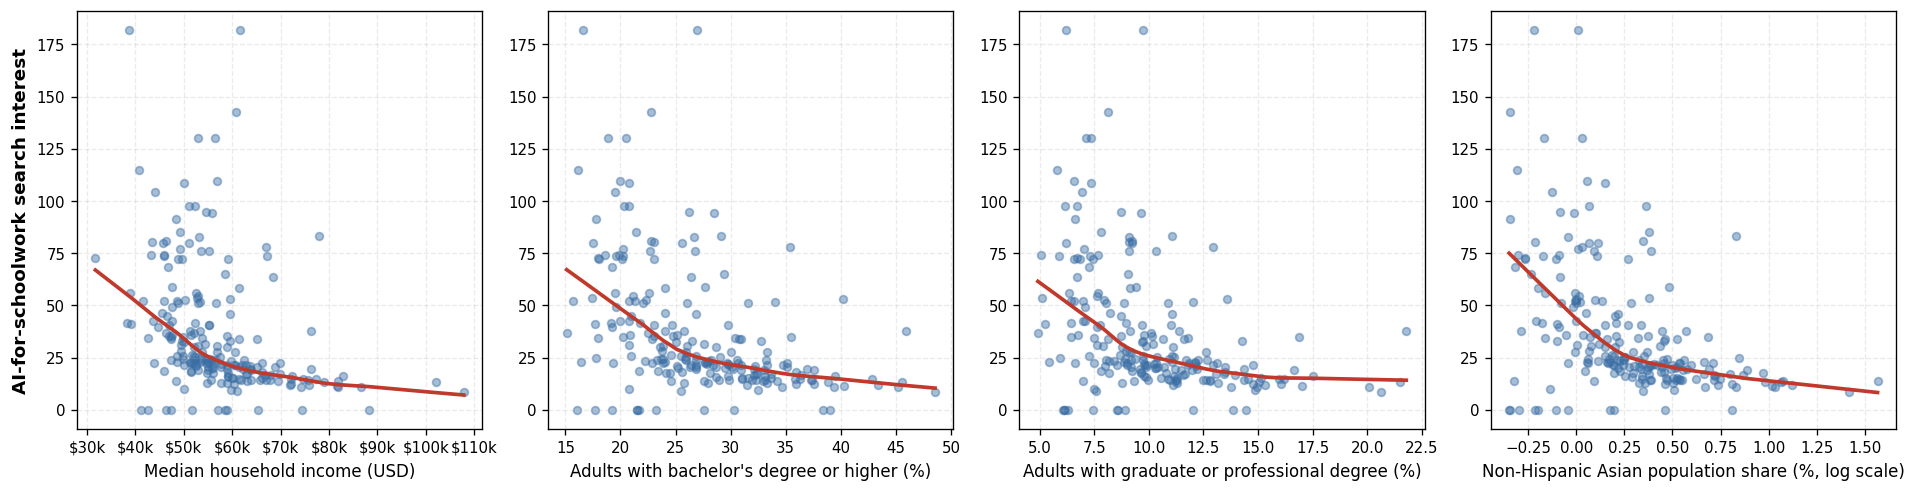

In [4]:
# Regenerate the 4-panel LOWESS figure (paper Figure 1)
PANELS = [
    ("median_income", "Median household income (USD)", False),
    ("bach_plus_rate", "Adults with bachelor's degree or higher (%)", False),
    ("grad_prof_rate", "Adults with graduate or professional degree (%)", False),
    ("pct_nh_asian", "Non-Hispanic Asian population share (%, log scale)", True),
]

predictors = [p for p, _, _ in PANELS]
imp = SimpleImputer(strategy="mean")
X = pd.DataFrame(imp.fit_transform(df[predictors]),
                 columns=predictors, index=df.index)
y = df["search_interest"].fillna(0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (col, xlabel, log_x) in zip(axes, PANELS):
    x = X[col]
    x_plot = np.log10(x.replace(0, np.nan)) if log_x else x
    sns.regplot(
        x=x_plot, y=y, ax=ax, lowess=True,
        scatter_kws={"alpha": 0.45, "s": 22, "color": "#3a6ea5"},
        line_kws={"color": "#c0392b", "linewidth": 2.2},
    )
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(True, alpha=0.25, linestyle="--")
    if col == "median_income":
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f"${int(v/1000)}k"))

axes[0].set_ylabel("AI-for-schoolwork search interest",
                    fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()
print("Figure 1 (4-panel LOWESS) regenerated. Saved version is at",
      "paper/figures/fig_lowess.pdf and is built by paper/build_lowess_figure.py.")